# Modelos predictivos de progresión en ELA
## Objetivo: entrenar y comparar modelos de clasificación para predecir 
## si un paciente tendrá progresión rápida o lenta de la enfermedad

Este notebook implementa tres modelos de clasificación supervisada:
1. Regresión Logística — modelo base de referencia
2. Árbol de Decisión — modelo interpretable y visualizable
3. Random Forest — modelo principal de mayor potencia predictiva

Para cada modelo se describe su fundamento teórico, se entrena sobre el 
dataset procesado en 02_preprocesamiento.ipynb y se evalúa con métricas 
clínicamente relevantes.

## 1. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from matplotlib.gridspec import GridSpec
from sklearn.pipeline import Pipeline

import seaborn as sns
from sklearn.model_selection import train_test_split,learning_curve, ShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, precision_recall_curve, average_precision_score,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,f1_score, precision_score, recall_score)
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ Librerías cargadas")

✅ Librerías cargadas


### Carga del dataset procesado

In [2]:
ruta = r"C:\Users\Paula\SAD_ELA\datos_procesados/"

df = pd.read_csv(ruta + "datos_modelos.csv")

print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nDistribución variable objetivo:")
print(df['progresion_rapida'].value_counts())
print(f"\nProgresión rápida: {df['progresion_rapida'].mean()*100:.1f}%")

Shape: (2219, 22)

Columnas: ['subject_id', 'progresion_rapida', 'Age', 'Sex', 'alsfrs_basal_total', 'basal_bulbar', 'basal_motor_fino', 'basal_motor_grueso', 'basal_respiratorio', 'onset_limb', 'onset_bulbar', 'onset_spine', 'onset_limb_bulbar', 'onset_other', 'onset_unknown', 'fvc_basal', 'weight_basal', 'albumin', 'creatine_kinase', 'creatinine', 'uric_acid', 'uric_acid_unknown']

Distribución variable objetivo:
progresion_rapida
0    1248
1     971
Name: count, dtype: int64

Progresión rápida: 43.8%


## 2. Preparación de los datos para el modelado

### 2.1 Separación de variables predictoras y variable objetivo

Separamos el dataset en:
- **X** → matriz de variables predictoras (todo excepto la variable objetivo 
  y columnas identificadoras)
- **y** → vector de la variable objetivo (`progresion_rapida`: 0 o 1)

In [3]:
# Variables que NO son predictoras
cols_excluir = ['subject_id', 'progresion_rapida']

X = df.drop(columns=cols_excluir)
y = df['progresion_rapida']

print("Variables predictoras:", X.columns.tolist())
print(f"\nNúmero de variables: {X.shape[1]}")
print(f"Número de pacientes: {X.shape[0]}")

Variables predictoras: ['Age', 'Sex', 'alsfrs_basal_total', 'basal_bulbar', 'basal_motor_fino', 'basal_motor_grueso', 'basal_respiratorio', 'onset_limb', 'onset_bulbar', 'onset_spine', 'onset_limb_bulbar', 'onset_other', 'onset_unknown', 'fvc_basal', 'weight_basal', 'albumin', 'creatine_kinase', 'creatinine', 'uric_acid', 'uric_acid_unknown']

Número de variables: 20
Número de pacientes: 2219


### 2.2 División train/test

Dividimos el dataset en dos subconjuntos:
- **Train (80%)**: datos con los que el modelo aprende los patrones
- **Test (20%)**: datos que el modelo nunca ha visto, usados exclusivamente 
  para evaluar su rendimiento real

Esta separación es fundamental para evitar el **overfitting**; si evaluáramos 
el modelo con los mismos datos con los que aprendió, obtendríamos resultados 
artificialmente buenos que no se generalizarían a pacientes nuevos.

Se ha fijado un valor de `random_state` para garantizar la **reproducibilidad**; cualquier persona que ejecute este código obtendrá exactamente la misma división.

In [4]:
# Almacenamiento de índice para poder ejecutar sección 12
idx= df.index
#

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, idx, test_size=0.2, random_state=11, stratify=y
)

print(f"Pacientes para entrenar: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Pacientes para evaluar:  {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nDistribución en train:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nDistribución en test:")
print(y_test.value_counts(normalize=True).round(3))

Pacientes para entrenar: 1775 (80%)
Pacientes para evaluar:  444 (20%)

Distribución en train:
progresion_rapida
0    0.562
1    0.438
Name: proportion, dtype: float64

Distribución en test:
progresion_rapida
0    0.563
1    0.437
Name: proportion, dtype: float64


### 2.3 Estandarización de variables numéricas

La **estandarización** transforma cada variable para que tenga media 0 y 
desviación estándar 1:

$$z = \frac{x - \mu}{\sigma}$$

Es esencial para la Regresión Logística porque:
- El algoritmo es sensible a la escala de las variables
- Sin estandarizar, variables con rangos grandes (ej. peso en kg) dominarían 
  artificialmente sobre variables con rangos pequeños (ej. pendiente ALSFRS)

El Árbol de Decisión y Random Forest **no la requieren** (son invariantes a 
escala)porque trabajan con umbrales relativos, no con magnitudes absolutas; pero aplicarla no les perjudica, así que usamos los mismos datos 
para todos los modelos por consistencia.

⚠️ **Fundamental**: el scaler se ajusta SOLO sobre train y se aplica 
sobre test; nunca al revés, para no introducir información del futuro (data leakage).

In [5]:
# Ajustar el scaler solo con train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convertir a dataframe para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("✅ Estandarización completada")
print("\nMedia de variables tras estandarización (train):")
print(X_train_scaled.mean().round(3))

✅ Estandarización completada

Media de variables tras estandarización (train):
Age                  -0.0
Sex                   0.0
alsfrs_basal_total   -0.0
basal_bulbar         -0.0
basal_motor_fino     -0.0
basal_motor_grueso   -0.0
basal_respiratorio    0.0
onset_limb            0.0
onset_bulbar         -0.0
onset_spine           0.0
onset_limb_bulbar    -0.0
onset_other           0.0
onset_unknown         0.0
fvc_basal             0.0
weight_basal          0.0
albumin               0.0
creatine_kinase       0.0
creatinine            0.0
uric_acid            -0.0
uric_acid_unknown     0.0
dtype: float64


## 3. Modelo 1 — Regresión Logística

### Fundamento teórico

La Regresión Logística es un algoritmo de clasificación que estima la 
**probabilidad** de que un paciente pertenezca a la clase positiva 
(progresión rápida = 1).

A diferencia de la regresión lineal, que predice valores continuos, 
la regresión logística aplica la **función sigmoide** a la combinación 
lineal de las variables:

    P(rápida) = 1 / (1 + e^-(β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ))

Donde:
- β₀ es el término independiente (intercept)
- β₁...βₙ son los coeficientes de cada variable
- x₁...xₙ son los valores de las variables del paciente

La función sigmoide transforma cualquier valor real en un número entre 
0 y 1, interpretable como probabilidad. Si P > 0.5, el modelo predice 
progresión rápida.

**Ventaja principal:** los coeficientes β son directamente interpretables;
un coeficiente positivo indica que esa variable aumenta la probabilidad 
de progresión rápida, y uno negativo la reduce.

**Limitación:** asume que la relación entre las variables y el resultado 
es lineal en el espacio logarítmico, lo cual no siempre se cumple en 
datos clínicos complejos.

Usamos `max_iter=1000` para asegurar la convergencia del algoritmo con 
nuestro número de variables.

In [6]:
# Entrenar modelo
lr = LogisticRegression(max_iter=1000, random_state=11)
lr.fit(X_train_scaled, y_train)

# Predicciones
y_pred_lr  = lr.predict(X_test_scaled)
y_prob_lr  = lr.predict_proba(X_test_scaled)[:, 1]

print("✅ Regresión Logística entrenada")
print(f"\nAUC-ROC: {roc_auc_score(y_test, y_prob_lr):.3f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_lr, 
      target_names=['Lenta (0)', 'Rápida (1)']))

✅ Regresión Logística entrenada

AUC-ROC: 0.633

Reporte de clasificación:
              precision    recall  f1-score   support

   Lenta (0)       0.62      0.78      0.69       250
  Rápida (1)       0.58      0.38      0.46       194

    accuracy                           0.61       444
   macro avg       0.60      0.58      0.58       444
weighted avg       0.60      0.61      0.59       444



### Interpretación de métricas

Las métricas de evaluación nos indican la calidad del modelo desde 
distintos ángulos:

- **Accuracy**: porcentaje de pacientes clasificados correctamente. 
  Es una métrica general pero puede ser engañosa si las clases 
  están desbalanceadas.
- **Precisión**: de todos los pacientes que el modelo predice como 
  "progresión rápida", ¿qué porcentaje realmente lo es? Mide los 
  falsos positivos.
- **Recall (sensibilidad)**: de todos los pacientes que realmente 
  tienen progresión rápida, ¿qué porcentaje detecta el modelo? 
  Mide los falsos negativos.
- **F1**: media armónica de precisión y recall. Útil cuando ambas 
  métricas son importantes.
- **AUC-ROC**: área bajo la curva ROC. Mide la capacidad del modelo 
  para discriminar entre las dos clases independientemente del umbral. 
  0.5 = azar, 1.0 = modelo perfecto.

En un contexto clínico como este, el **Recall** es especialmente 
importante; no detectar a un paciente con progresión rápida 
(falso negativo) tiene consecuencias clínicas más graves que 
clasificar incorrectamente a uno lento.

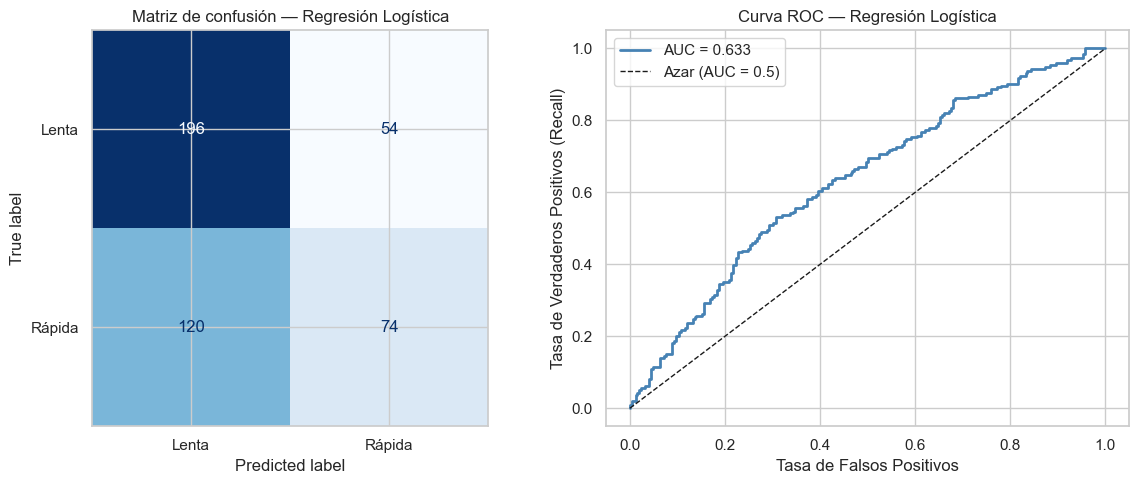

✅ Gráficas guardadas


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Lenta', 'Rápida'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusión — Regresión Logística')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc = roc_auc_score(y_test, y_prob_lr)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, 
             label=f'AUC = {auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Azar (AUC = 0.5)')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[1].set_title('Curva ROC — Regresión Logística')
axes[1].legend()

plt.tight_layout()
plt.savefig(ruta + "graf_roc_lr.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráficas guardadas")

## 4. Modelo 2 — Árbol de Decisión

### Fundamento teórico

Un Árbol de Decisión es un modelo que aprende una serie de **reglas de 
división** jerárquicas a partir de los datos. Funciona haciendo preguntas 
binarias sucesivas sobre las variables — cada pregunta divide el conjunto 
de pacientes en dos grupos más homogéneos hasta llegar a una clasificación.

Por ejemplo:
    ¿alsfrs_basal_total < 38?
    ├── Sí → ¿onset_bulbar = 1?
    │         ├── Sí → Progresión RÁPIDA
    │         └── No → Progresión LENTA
    └── No → Progresión LENTA

El algoritmo elige en cada nodo la variable y el umbral que mejor separan 
las clases, usando el criterio **Gini**; una medida de impureza que vale 
0 cuando todos los pacientes del nodo son de la misma clase (nodo puro) 
y 0.5 cuando están mezclados al 50%.

**Ventaja principal:** el resultado es completamente interpretable y 
visualizable; el clínico puede seguir el camino de decisión de cada 
paciente paso a paso.

**Limitación principal:** tiende al **overfitting**; si no se limita 
su profundidad, el árbol memoriza los datos de entrenamiento y falla 
con datos nuevos. Por eso usamos `max_depth=4` para limitarlo a 4 
niveles de profundidad.

In [8]:
# Entrenar modelo
dt = DecisionTreeClassifier(max_depth=4, random_state=11, criterion='gini')
dt.fit(X_train, y_train)

# Predicciones (sin estandarizar — el árbol no lo necesita)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("✅ Árbol de Decisión entrenado")
print(f"\nAUC-ROC: {roc_auc_score(y_test, y_prob_dt):.3f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_dt,
      target_names=['Lenta (0)', 'Rápida (1)']))

✅ Árbol de Decisión entrenado

AUC-ROC: 0.584

Reporte de clasificación:
              precision    recall  f1-score   support

   Lenta (0)       0.65      0.52      0.58       250
  Rápida (1)       0.51      0.64      0.57       194

    accuracy                           0.57       444
   macro avg       0.58      0.58      0.57       444
weighted avg       0.59      0.57      0.58       444



### Visualización del árbol

Una de las grandes ventajas del Árbol de Decisión es que puede 
representarse visualmente. Cada nodo muestra:
- La pregunta de división (variable y umbral)
- El criterio Gini (impureza del nodo)
- El número de pacientes en ese nodo
- La clase mayoritaria

Esta visualización es especialmente valiosa en un SAD clínico porque 
permite al médico entender exactamente qué variables y qué umbrales 
usa el modelo para tomar cada decisión.

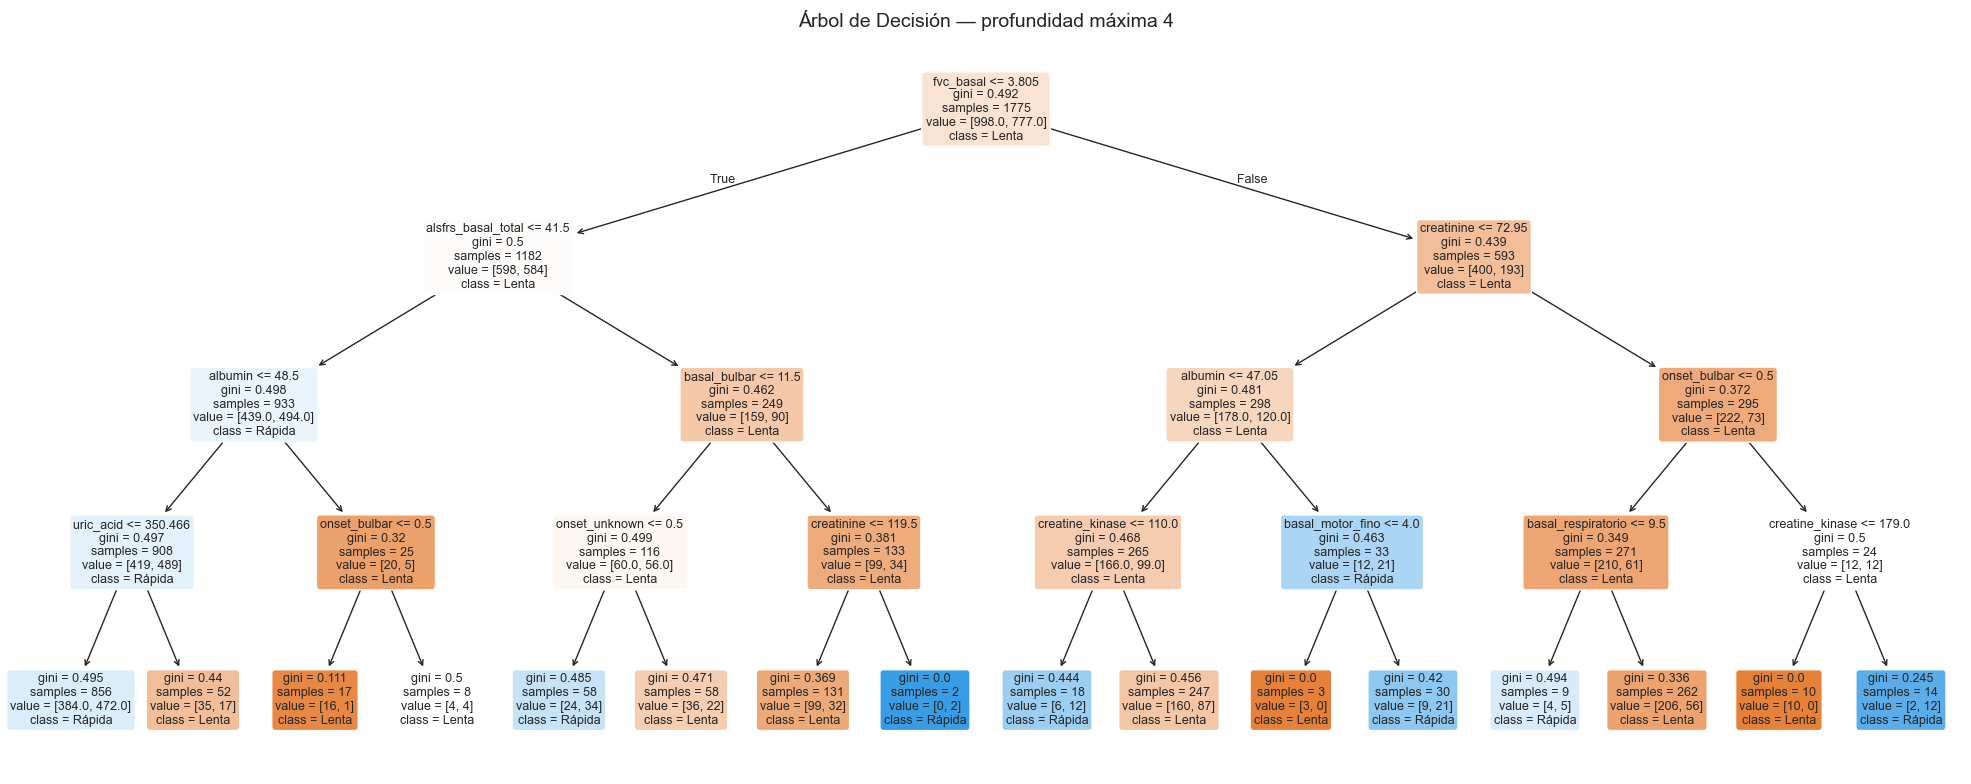

✅ Árbol guardado
|--- fvc_basal <= 3.80
|   |--- alsfrs_basal_total <= 41.50
|   |   |--- albumin <= 48.50
|   |   |   |--- uric_acid <= 350.47
|   |   |   |   |--- class: 1
|   |   |   |--- uric_acid >  350.47
|   |   |   |   |--- class: 0
|   |   |--- albumin >  48.50
|   |   |   |--- onset_bulbar <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- onset_bulbar >  0.50
|   |   |   |   |--- class: 0
|   |--- alsfrs_basal_total >  41.50
|   |   |--- basal_bulbar <= 11.50
|   |   |   |--- onset_unknown <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- onset_unknown >  0.50
|   |   |   |   |--- class: 0
|   |   |--- basal_bulbar >  11.50
|   |   |   |--- creatinine <= 119.50
|   |   |   |   |--- class: 0
|   |   |   |--- creatinine >  119.50
|   |   |   |   |--- class: 1
|--- fvc_basal >  3.80
|   |--- creatinine <= 72.95
|   |   |--- albumin <= 47.05
|   |   |   |--- creatine_kinase <= 110.00
|   |   |   |   |--- class: 1
|   |   |   |--- creatine_kinase >  110.00
|   |   |   | 

In [9]:
fig, ax = plt.subplots(figsize=(20, 8))

plot_tree(dt, 
          feature_names=X.columns.tolist(),
          class_names=['Lenta', 'Rápida'],
          filled=True,
          rounded=True,
          fontsize=9,
          ax=ax)

ax.set_title('Árbol de Decisión — profundidad máxima 4', fontsize=14)
plt.tight_layout()
plt.savefig(ruta + "graf_arbol_decision.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Árbol guardado")

from sklearn.tree import export_text
reglas = export_text(dt, feature_names=X.columns.tolist(), max_depth=3)
print(reglas)

#### Modificación de max_depth=3 para sencillez de visualización.

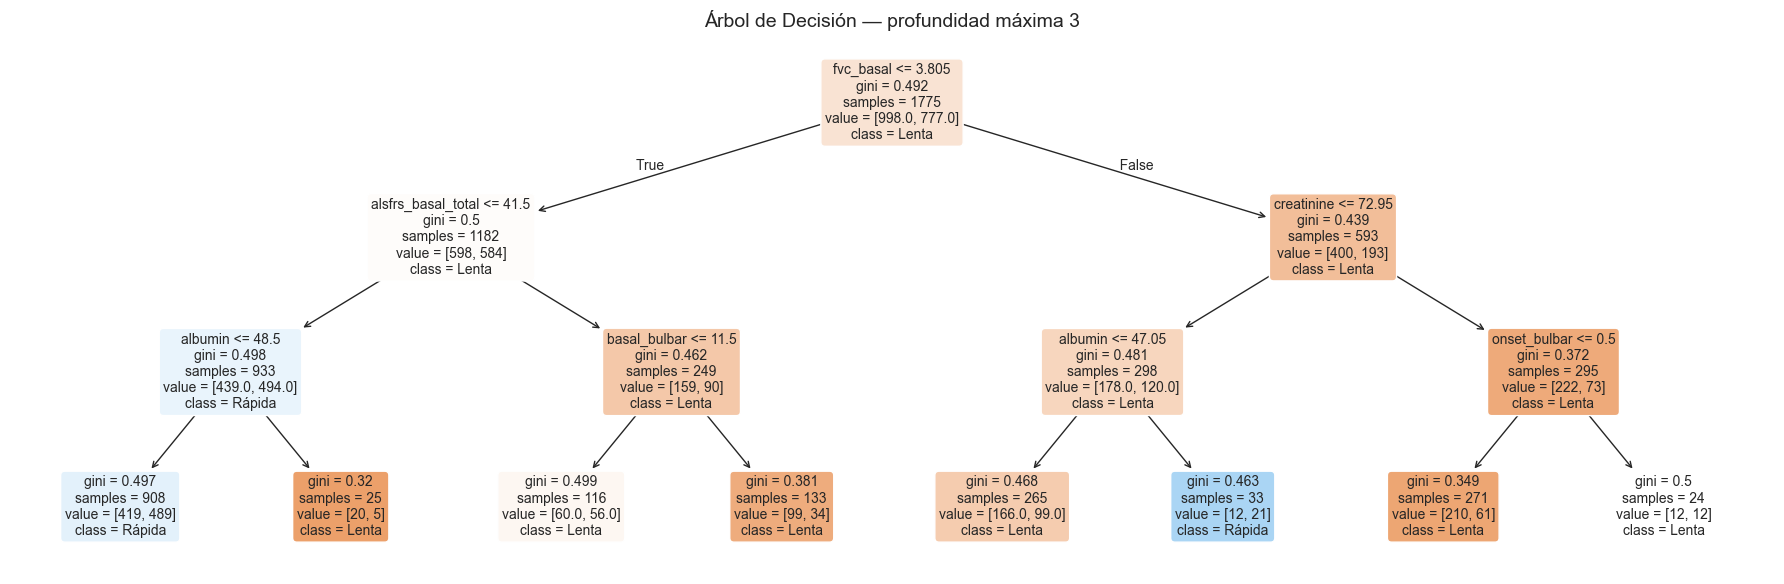

In [10]:
dt_visual = DecisionTreeClassifier(max_depth=3, random_state=11, criterion='gini')
dt_visual.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(dt_visual,
          feature_names=X.columns.tolist(),
          class_names=['Lenta', 'Rápida'],
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax)
ax.set_title('Árbol de Decisión — profundidad máxima 3', fontsize=14)
plt.tight_layout()
plt.savefig(ruta + "graf_arbol_decision_simplificado.png", dpi=200, bbox_inches='tight')
plt.show()

### Visualización — Matriz de confusión y curva ROC

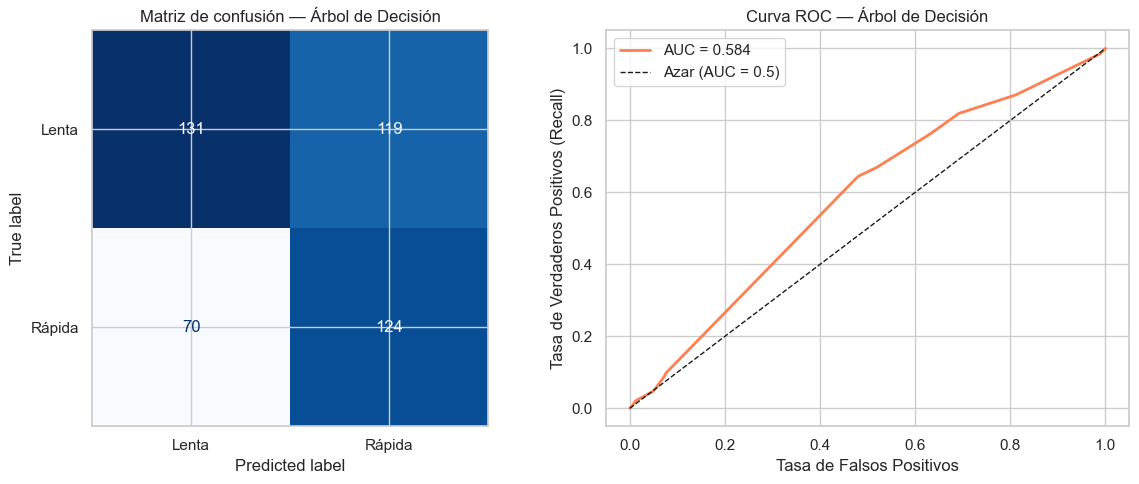

✅ Gráficas guardadas


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Lenta', 'Rápida'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusión — Árbol de Decisión')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
auc = roc_auc_score(y_test, y_prob_dt)
axes[1].plot(fpr, tpr, color='coral', lw=2,
             label=f'AUC = {auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Azar (AUC = 0.5)')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[1].set_title('Curva ROC — Árbol de Decisión')
axes[1].legend()

plt.tight_layout()
plt.savefig(ruta + "graf_roc_dt.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráficas guardadas")

## 5. Modelo 3 — Random Forest

### Fundamento teórico

El Random Forest es un método de **aprendizaje en conjunto (ensemble)** 
que construye múltiples árboles de decisión y combina sus predicciones 
mediante votación mayoritaria.

Para evitar que todos los árboles sean iguales, introduce dos fuentes 
de aleatoriedad:

1. **Bagging (Bootstrap Aggregating):** cada árbol se entrena con una 
   muestra aleatoria con reemplazamiento del conjunto de entrenamiento. 
   Esto significa que cada árbol ve aproximadamente el 63% de los datos 
   originales y el resto queda fuera (out-of-bag samples).

2. **Selección aleatoria de variables:** en cada nodo, en lugar de 
   evaluar todas las variables posibles para la división, solo evalúa 
   un subconjunto aleatorio de ellas. Esto desorrela los árboles entre 
   sí, haciendo que cada uno capture patrones distintos.

La predicción final se obtiene por **votación mayoritaria**; si 60 de 
100 árboles predicen "progresión rápida", el modelo predice rápida.

**Ventaja principal:** al promediar muchos árboles, el Random Forest 
reduce drásticamente el overfitting que afecta a un solo árbol. Es 
actualmente uno de los algoritmos más utilizados en datos clínicos por 
su robustez y buen rendimiento sin necesidad de mucho ajuste.

**Ventaja adicional:** proporciona una medida de **importancia de variables**;
indica cuánto contribuye cada variable a la reducción de impureza Gini 
a lo largo de todos los árboles. Esto es especialmente valioso en un SAD 
clínico porque permite identificar qué factores son más predictivos.

**Parámetros clave:**
- `n_estimators=100` → número de árboles. Más árboles = más estable 
  pero más lento. 100 es un valor estándar suficiente para nuestro dataset.
- `max_depth=None` → los árboles crecen hasta que los nodos son puros. 
  El bagging ya controla el overfitting sin necesitar limitar la profundida

In [12]:
# Entrenar modelo
rf = RandomForestClassifier(n_estimators=100, random_state=11, n_jobs=-1)
rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print("✅ Random Forest entrenado")
print(f"\nAUC-ROC: {roc_auc_score(y_test, y_prob_rf):.3f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Lenta (0)', 'Rápida (1)']))

✅ Random Forest entrenado

AUC-ROC: 0.622

Reporte de clasificación:
              precision    recall  f1-score   support

   Lenta (0)       0.64      0.72      0.68       250
  Rápida (1)       0.57      0.46      0.51       194

    accuracy                           0.61       444
   macro avg       0.60      0.59      0.59       444
weighted avg       0.60      0.61      0.60       444



### Importancia de variables

Una de las grandes ventajas del Random Forest en un contexto clínico es 
que proporciona una medida de **importancia de cada variable** ; cuánto 
contribuye en promedio a mejorar la pureza de los nodos a lo largo de 
todos los árboles.

Esta información es clínicamente valiosa porque permite identificar qué 
factores son más predictivos de la progresión rápida, lo cual puede 
orientar al clínico sobre qué variables monitorizar más estrechamente.

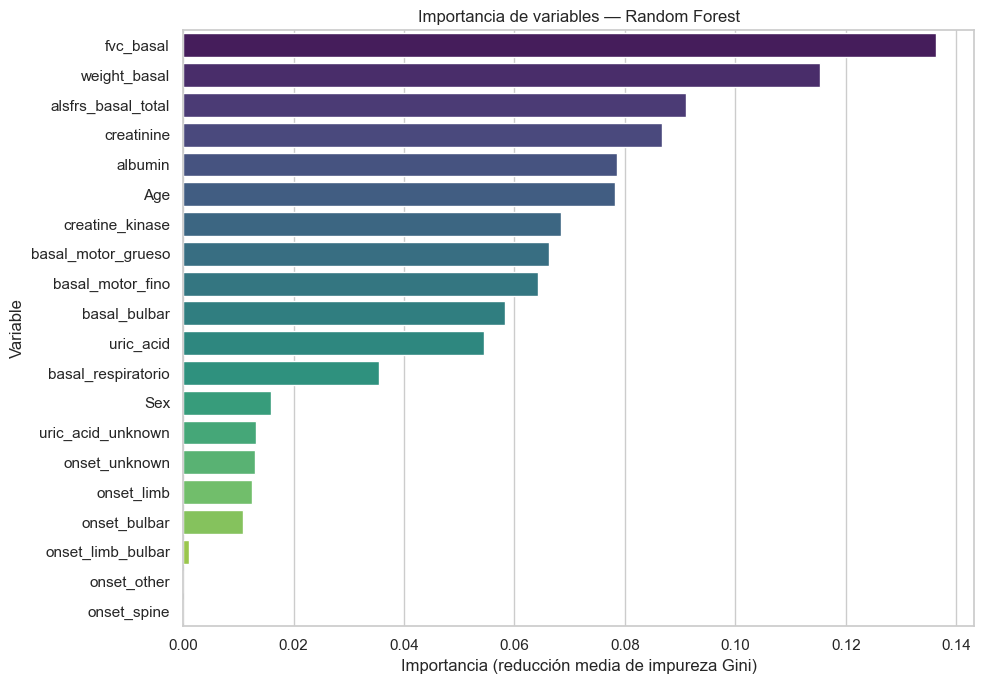


Top 5 variables más importantes:
          variable  importancia
         fvc_basal     0.136414
      weight_basal     0.115385
alsfrs_basal_total     0.091115
        creatinine     0.086742
           albumin     0.078603


In [13]:
# Importancia de variables
importancias = pd.DataFrame({
    'variable': X.columns,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=importancias, x='importancia', y='variable', 
            palette='viridis', ax=ax, hue='variable', legend=False)
ax.set_title('Importancia de variables — Random Forest')
ax.set_xlabel('Importancia (reducción media de impureza Gini)')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.savefig(ruta + "graf_importancia_rf.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 variables más importantes:")
print(importancias.head(5).to_string(index=False))

### Visualización — Importancia de variables, matriz de confusión y curva ROC

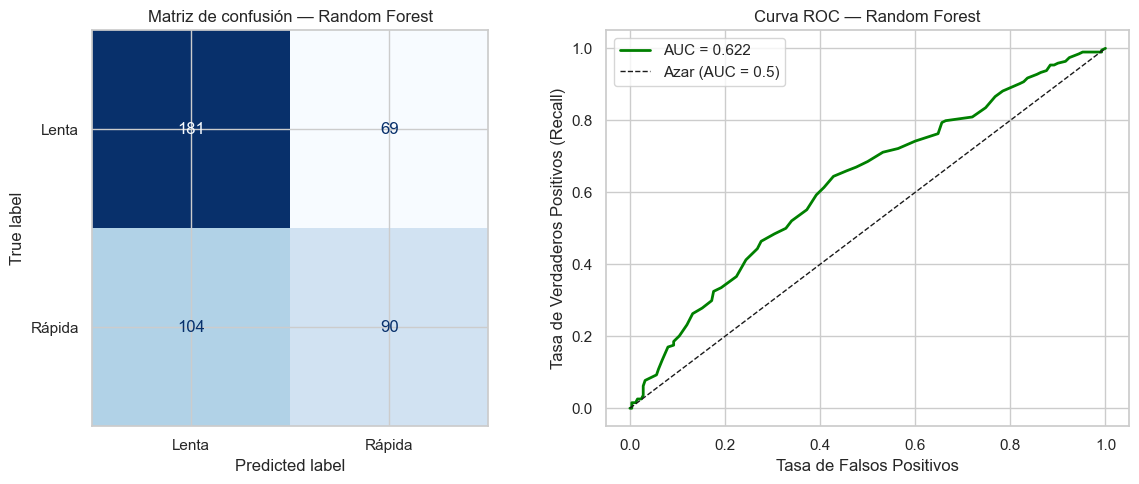

✅ Gráficas guardadas


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Lenta', 'Rápida'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusión — Random Forest')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc = roc_auc_score(y_test, y_prob_rf)
axes[1].plot(fpr, tpr, color='green', lw=2,
             label=f'AUC = {auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Azar (AUC = 0.5)')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[1].set_title('Curva ROC — Random Forest')
axes[1].legend()

plt.tight_layout()
plt.savefig(ruta + "graf_roc_rf.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráficas guardadas")

## 6. Comparativa de modelos

### Fundamento teórico

La comparación sistemática de modelos es una práctica estándar en 
machine learning clínico. No existe un algoritmo universalmente superior;
cada modelo tiene fortalezas y debilidades que dependen de los datos, 
el tamaño del dataset y el objetivo clínico.

En este trabajo comparamos tres modelos con filosofías distintas:
- **Regresión Logística**: modelo lineal, interpretable, estable
- **Árbol de Decisión**: modelo no lineal, muy interpretable, propenso 
  a overfitting
- **Random Forest**: ensemble de árboles, menos interpretable pero más 
  robusto

La métrica principal de comparación es el **AUC-ROC** por ser independiente 
del umbral de clasificación. Como métrica secundaria usamos el **Recall** 
en la clase positiva (progresión rápida) por su relevancia clínica;
no detectar a un paciente con progresión rápida tiene consecuencias 
más graves que un falso positivo.

In [15]:
# Tabla comparativa
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'Random Forest'],
    'AUC-ROC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ],
    'Accuracy': [
        (y_pred_lr == y_test).mean(),
        (y_pred_dt == y_test).mean(),
        (y_pred_rf == y_test).mean()
    ],
    'Recall_Rapida': [
        classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_dt, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall']
    ],
    'F1_Rapida': [
        classification_report(y_test, y_pred_lr, output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_pred_dt, output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_pred_rf, output_dict=True)['1']['f1-score']
    ]
}).round(3)

print(resultados.to_string(index=False))

             Modelo  AUC-ROC  Accuracy  Recall_Rapida  F1_Rapida
Regresión Logística    0.633     0.608          0.381      0.460
  Árbol de Decisión    0.584     0.574          0.639      0.568
      Random Forest    0.622     0.610          0.464      0.510


### Curvas ROC comparativas

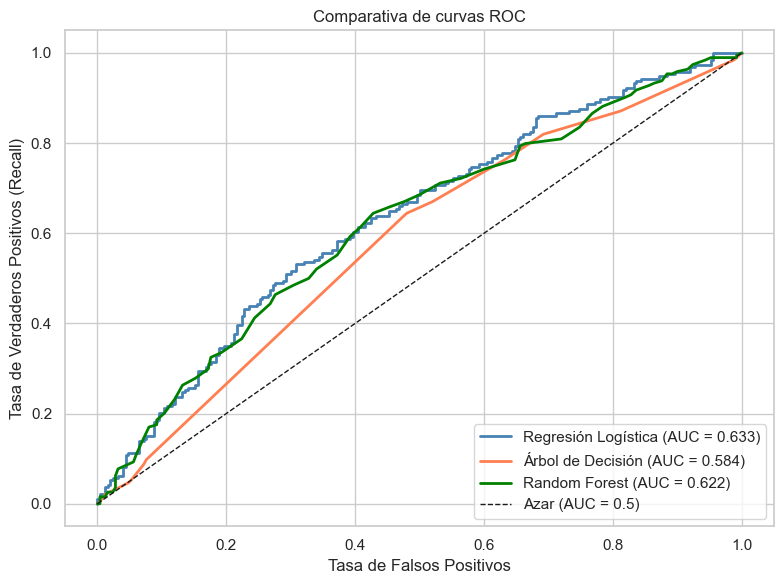

✅ Gráfica guardada


In [16]:
# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(8, 6))

modelos = [
    ('Regresión Logística', y_prob_lr, 'steelblue'),
    ('Árbol de Decisión',   y_prob_dt, 'coral'),
    ('Random Forest',       y_prob_rf, 'green')
]

for nombre, y_prob, color in modelos:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC = {auc:.3f})')

ax.plot([0,1], [0,1], 'k--', lw=1, label='Azar (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax.set_title('Comparativa de curvas ROC')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(ruta + "graf_roc_comparativa.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada")

## 7. Interpretabilidad con SHAP

### Fundamento teórico

SHAP (SHapley Additive exPlanations) es un método de interpretabilidad 
de modelos de machine learning basado en la teoría de juegos cooperativos 
de Shapley (1953).

La idea central es: dado un modelo entrenado y una predicción concreta, 
¿cuánto ha contribuido cada variable a esa predicción respecto a la 
predicción media del modelo?

Para cada paciente y cada variable, SHAP calcula un **valor SHAP** que 
puede ser positivo o negativo:
- **Valor SHAP positivo** → esa variable empuja la predicción hacia 
  "progresión rápida"
- **Valor SHAP negativo** → esa variable empuja la predicción hacia 
  "progresión lenta"
- **Valor SHAP = 0** → esa variable no influye en la predicción

A diferencia de la importancia de variables del Random Forest (que solo 
dice cuánto importa cada variable en global), SHAP explica **cada 
predicción individual**, podemos saber exactamente por qué el modelo 
clasificó a un paciente concreto como progresador rápido.

Esto es fundamental en un SAD clínico porque el médico no solo necesita 
saber que el modelo predice "rápida", necesita entender **por qué**, 
para poder confiar en la predicción y actuar en consecuencia.

Usamos `TreeExplainer` que es el método específico de SHAP para modelos 
basados en árboles como el Random Forest; es más eficiente y preciso 
que el método genérico.

In [17]:
# Calcular valores SHAP
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# shap_values tiene forma (n_pacientes, n_variables, 2 clases)
# Nos quedamos con los valores de la clase positiva (progresión rápida = 1)
shap_rapida = shap_values[:, :, 1]

print("✅ Valores SHAP calculados")
print(f"Shape de shap_values: {shap_rapida.shape}")
print(f"Pacientes: {shap_rapida.shape[0]}, Variables: {shap_rapida.shape[1]}")

✅ Valores SHAP calculados
Shape de shap_values: (444, 20)
Pacientes: 444, Variables: 20


### 7.1 Importancia global de variables según SHAP

La importancia global se calcula como el valor SHAP medio absoluto de
cada variable sobre todos los pacientes del conjunto de test.
A diferencia de la importancia del Random Forest (basada en reducción
de impureza Gini), la importancia SHAP es más precisa porque tiene en
cuenta las interacciones entre variables y no está sesgada hacia
variables con muchas categorías.

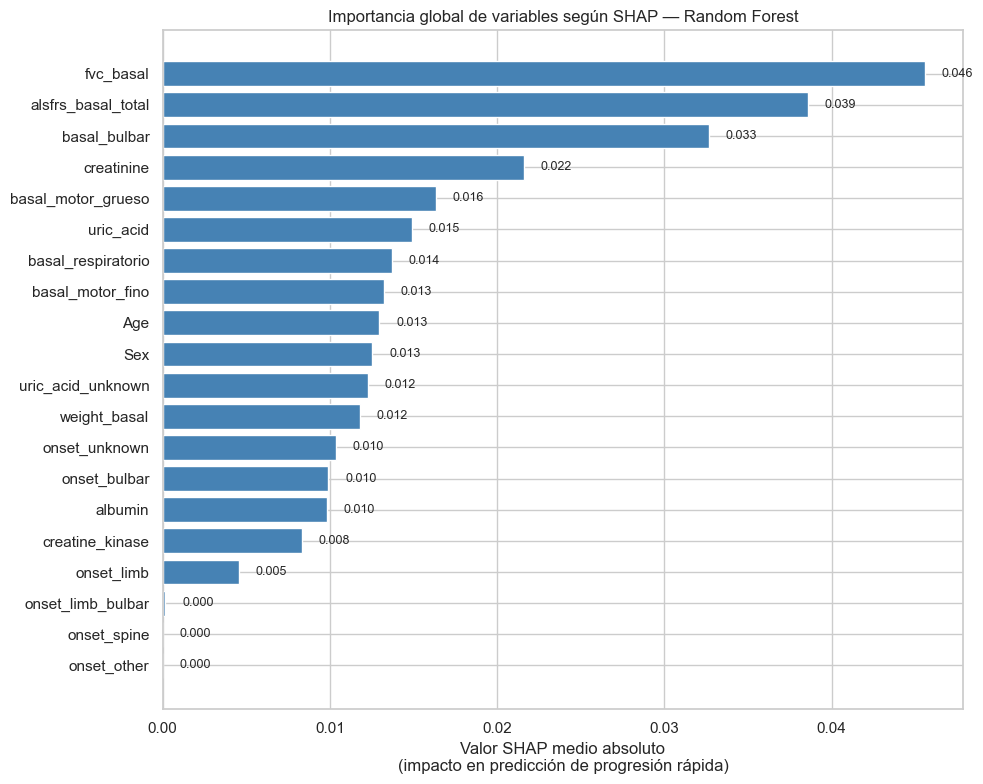

✅ Gráfica importancia global SHAP guardada


In [18]:
shap_medio = pd.DataFrame({
    'variable': X.columns,
    'shap_importance': np.abs(shap_rapida).mean(axis=0)
}).sort_values('shap_importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(shap_medio['variable'], shap_medio['shap_importance'],
               color='steelblue', edgecolor='white')
ax.set_xlabel('Valor SHAP medio absoluto\n(impacto en predicción de progresión rápida)')
ax.set_title('Importancia global de variables según SHAP — Random Forest')

for bar, val in zip(bars, shap_medio['shap_importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(ruta + "graf_shap_global.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica importancia global SHAP guardada")

### 7.2 Explicación individual por paciente — Waterfall plot

El waterfall plot muestra para un paciente concreto qué variables
empujaron la predicción hacia "progresión rápida" (rojo) y cuáles
hacia "progresión lenta" (azul), partiendo de la predicción base
del modelo (media sobre todos los pacientes).


### Selección de pacientes representativos para comparativa

Para la comparativa individual seleccionamos:
- Un paciente con progresión rápida que el modelo clasifique correctamente
  (verdadero positivo)
- Un paciente con progresión lenta que el modelo clasifique correctamente
  (verdadero negativo)

Adicionalmente documentamos un caso de falso negativo, paciente con
progresión rápida que el modelo clasifica incorrectamente como lenta,
para ilustrar las limitaciones del modelo desde una perspectiva clínica.

In [19]:
indices_rapidos = np.where(y_test.values == 1)[0]
indices_lentos  = np.where(y_test.values == 0)[0]

idx_rapido = indices_rapidos[0]
idx_lento  = indices_lentos[0]

# Buscar verdadero positivo (rápido que el modelo acierta)
for idx in indices_rapidos:
    if y_pred_rf[idx] == 1:
        idx_vp = idx
        break

# Buscar verdadero negativo (lento que el modelo acierta)
for idx in indices_lentos:
    if y_pred_rf[idx] == 0:
        idx_vn = idx
        break

print(f"Verdadero positivo — índice: {idx_vp}")
print(f"Predicción: {'Rápida' if y_pred_rf[idx_vp]==1 else 'Lenta'} | Realidad: {'Rápida' if y_test.values[idx_vp]==1 else 'Lenta'}")
print()
print(f"Verdadero negativo — índice: {idx_vn}")
print(f"Predicción: {'Rápida' if y_pred_rf[idx_vn]==1 else 'Lenta'} | Realidad: {'Rápida' if y_test.values[idx_vn]==1 else 'Lenta'}")
print()
print(f"Falso negativo — índice: {idx_rapido}")
print(f"Predicción: {'Rápida' if y_pred_rf[idx_rapido]==1 else 'Lenta'} | Realidad: {'Rápida' if y_test.values[idx_rapido]==1 else 'Lenta'}")

Verdadero positivo — índice: 3
Predicción: Rápida | Realidad: Rápida

Verdadero negativo — índice: 0
Predicción: Lenta | Realidad: Lenta

Falso negativo — índice: 2
Predicción: Lenta | Realidad: Rápida


### 7.3 Waterfall plots — explicación individual de predicciones

Analizamos tres casos representativos:
1. **Verdadero positivo**: paciente con progresión rápida correctamente
   identificado por el modelo
2. **Verdadero negativo**: paciente con progresión lenta correctamente
   identificado por el modelo
3. **Falso negativo**: paciente con progresión rápida que el modelo
   clasifica incorrectamente como lenta — caso clínicamente relevante
   que ilustra las limitaciones del sistema

En cada waterfall plot:
- **Barras rojas** → variables que empujan hacia progresión rápida
- **Barras azules** → variables que empujan hacia progresión lenta
- **E[f(x)]** → predicción base del modelo (media sobre todos los pacientes)
- **f(x)** → predicción final para ese paciente
- El valor entre paréntesis es el valor real de la variable para ese paciente

#### Verdadero positivo — paciente rápido identificado correctamente

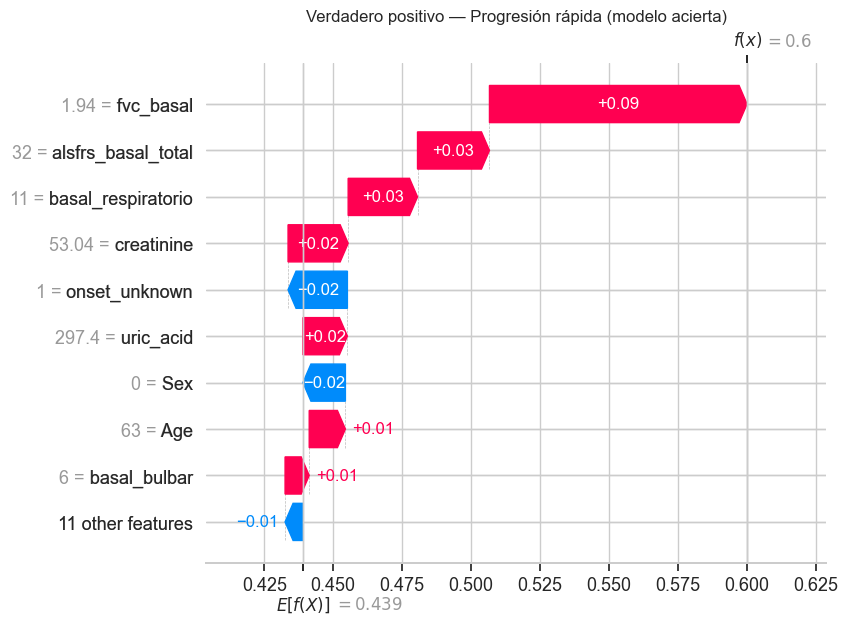

✅ Waterfall verdadero positivo guardado


In [20]:
explanation = shap.Explanation(
    values=shap_rapida,
    base_values=explainer.expected_value[1],
    data=X_test.values,
    feature_names=X.columns.tolist()
)

# Verdadero positivo
shap.waterfall_plot(explanation[idx_vp], show=False)
plt.title('Verdadero positivo — Progresión rápida (modelo acierta)')
plt.savefig(ruta + "graf_shap_waterfall_vp.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Waterfall verdadero positivo guardado")

#### Verdadero negativo — paciente lento identificado correctamente

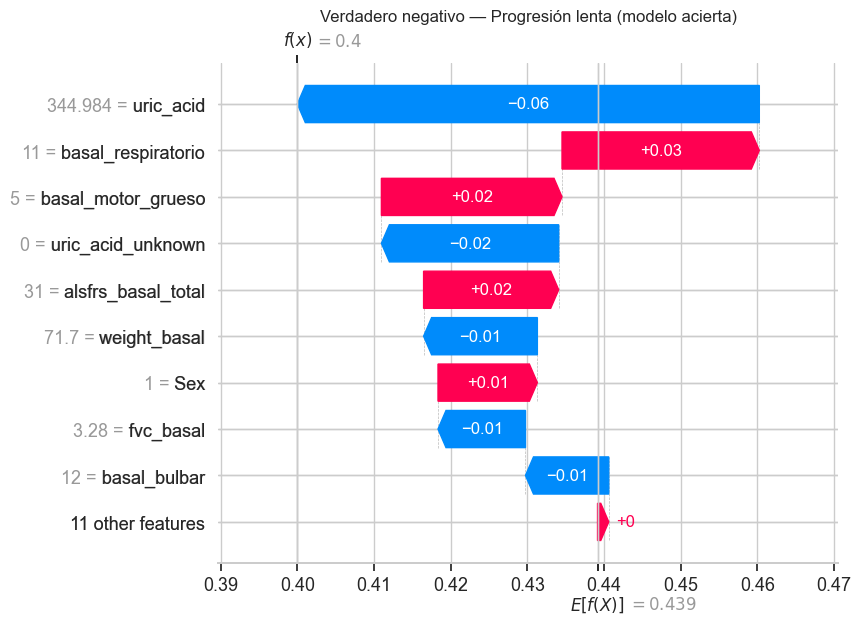

✅ Waterfall verdadero negativo guardado


In [21]:
# Verdadero negativo
shap.waterfall_plot(explanation[idx_vn], show=False)
plt.title('Verdadero negativo — Progresión lenta (modelo acierta)')
plt.savefig(ruta + "graf_shap_waterfall_vn.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Waterfall verdadero negativo guardado")

#### Falso negativo — progresor rápido clasificado como lento

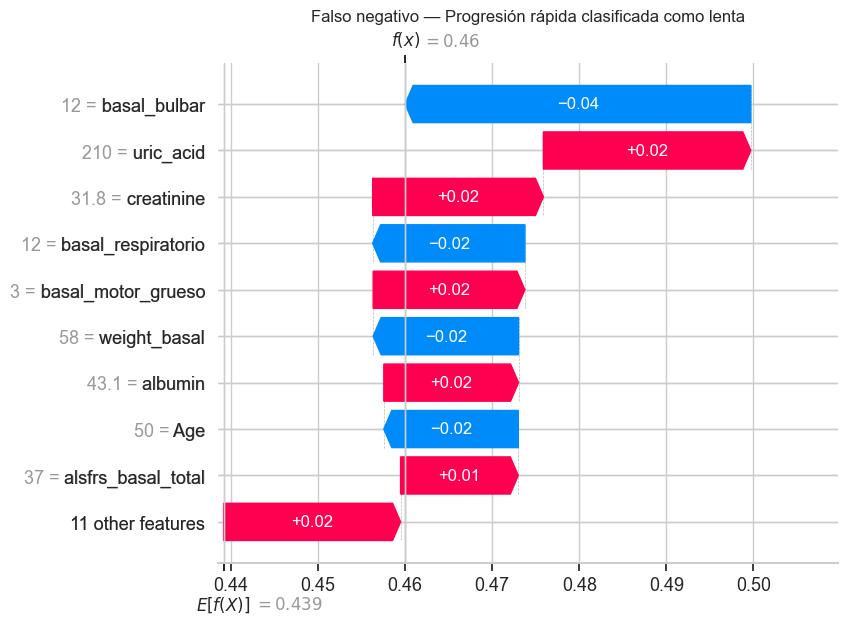

✅ Waterfall falso negativo guardado


In [22]:
# Falso negativo
shap.waterfall_plot(explanation[idx_rapido], show=False)
plt.title('Falso negativo — Progresión rápida clasificada como lenta')
plt.savefig(ruta + "graf_shap_waterfall_fn.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Waterfall falso negativo guardado")

### 7.4 Interpretación clínica de los waterfall plots

**Verdadero positivo (f(x) = 0.60):**
El modelo identificó correctamente la progresión rápida gracias a señales
clínicas claras: `fvc_basal = 1.94` litros (muy por debajo del valor normal
de 3-5L), `alsfrs_basal_total = 32` y `basal_respiratorio = 11` elevado.
El deterioro respiratorio severo desde el inicio fue el factor determinante.

**Verdadero negativo (f(x) = 0.40):**
El modelo identificó correctamente la progresión lenta gracias a valores
metabólicos protectores: `uric_acid = 344.98` (nivel alto, efecto protector
documentado por Atassi et al. 2014), `fvc_basal = 3.28` litros conservada
y `weight_basal = 71.7` kg normal.

**Falso negativo (f(x) = 0.46):**
El modelo clasificó incorrectamente a este paciente como lento cuando era
rápido. La predicción (0.46) quedó muy cerca del umbral de decisión (0.50),
lo que indica un perfil clínico ambiguo. `basal_bulbar = 12` (función bulbar
conservada) compensó otros factores de riesgo, llevando al modelo a una
predicción errónea. Este caso ilustra la limitación del modelo ante perfiles
mixtos y justifica la necesidad de supervisión clínica en cualquier SAD real.

## 8. Validación cruzada (k-fold)

Hasta ahora se ha evaluado los modelos con una única división train/test
(80%/20%). Esto tiene una limitación importante: el resultado depende de
qué pacientes cayeron en el conjunto de test por azar. Con otra semilla
aleatoria distinta podríamos obtener resultados diferentes.

La **validación cruzada k-fold** soluciona esto dividiendo el dataset en
**k partes iguales (folds)**. El proceso se repite k veces — en cada
iteración una parte diferente actúa como test y las k-1 restantes como
train. El resultado final es la media y desviación estándar de las k
evaluaciones.

Con k=5 (la elección más común) el proceso es:

    Iteración 1: [TEST] [train] [train] [train] [train]
    Iteración 2: [train] [TEST] [train] [train] [train]
    Iteración 3: [train] [train] [TEST] [train] [train]
    Iteración 4: [train] [train] [train] [TEST] [train]
    Iteración 5: [train] [train] [train] [train] [TEST]

**Ventajas:**
- Todos los pacientes actúan como test exactamente una vez
- El resultado es más estable y representativo del rendimiento real
- La desviación estándar nos dice qué tan consistente es el modelo

**Por qué es importante en datos clínicos:** con solo 2.219 pacientes,
una única división train/test puede ser poco representativa. La validación
cruzada nos da una estimación más honesta del rendimiento real del modelo
sobre pacientes nuevos.

In [23]:
from sklearn.model_selection import cross_validate, StratifiedKFold

# Definir el esquema de validación cruzada estratificada
# Estratificada = mantiene la proporción rápida/lenta en cada fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)

# Modelos a evaluar
modelos_cv = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=11),
    'Árbol de Decisión'  : DecisionTreeClassifier(max_depth=4, random_state=11),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=11, n_jobs=-1)
}

# Métricas a calcular
metricas = ['roc_auc', 'accuracy', 'recall', 'f1']

resultados_cv = {}

for nombre, modelo in modelos_cv.items():
    scores = cross_validate(modelo, X, y, cv=cv, scoring=metricas, n_jobs=-1)
    resultados_cv[nombre] = {
        'AUC-ROC'  : f"{scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}",
        'Accuracy' : f"{scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}",
        'Recall'   : f"{scores['test_recall'].mean():.3f} ± {scores['test_recall'].std():.3f}",
        'F1'       : f"{scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}"
    }
    print(f"✅ {nombre} completado")

print("\n=== Resultados validación cruzada 5-fold ===")
df_cv = pd.DataFrame(resultados_cv).T
print(df_cv.to_string())

✅ Regresión Logística completado
✅ Árbol de Decisión completado
✅ Random Forest completado

=== Resultados validación cruzada 5-fold ===
                           AUC-ROC       Accuracy         Recall             F1
Regresión Logística  0.633 ± 0.013  0.612 ± 0.015  0.403 ± 0.036  0.475 ± 0.031
Árbol de Decisión    0.588 ± 0.024  0.575 ± 0.026  0.368 ± 0.107  0.421 ± 0.069
Random Forest        0.610 ± 0.013  0.591 ± 0.016  0.427 ± 0.020  0.478 ± 0.019


### Interpretación de la validación cruzada

Los resultados se expresan como **media ± desviación estándar** sobre
los 5 folds. La desviación estándar es tan importante como la media:

- **Desviación estándar baja** → el modelo es consistente y estable,
  su rendimiento no depende de qué pacientes caen en el test
- **Desviación estándar alta** → el modelo es inestable, probablemente
  por overfitting o por sensibilidad a la distribución de los datos

Comparamos estos resultados con los obtenidos en la evaluación simple
train/test para verificar si nuestras estimaciones iniciales eran
representativas o estaban sesgadas por la división aleatoria.

## 9. Optimización de hiperparámetros — Grid Search

Los modelos de machine learning tienen **hiperparámetros**; parámetros
que no se aprenden de los datos sino que se fijan antes del entrenamiento
y controlan cómo aprende el modelo.

Por ejemplo en Random Forest:
- `n_estimators` → número de árboles
- `max_depth` → profundidad máxima de cada árbol
- `min_samples_split` → mínimo de pacientes para dividir un nodo
- `max_features` → número de variables evaluadas en cada división

Hasta ahora hemos usado los valores por defecto de scikit-learn. La
**optimización de hiperparámetros** busca sistemáticamente la combinación
que maximiza el rendimiento del modelo.

**Grid Search con validación cruzada** prueba todas las combinaciones
posibles de una rejilla de valores predefinida, evaluando cada una con
validación cruzada para evitar overfitting. Es computacionalmente costoso
pero garantiza encontrar el óptimo dentro de la rejilla definida.

Optimizamos el **Random Forest** por ser el modelo principal del trabajo.
Usamos **AUC-ROC** como métrica de optimización por ser la más adecuada
en contexto clínico con clases moderadamente desbalanceadas.

In [24]:
from sklearn.model_selection import GridSearchCV

# Rejilla de hiperparámetros a explorar
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features' : ['sqrt', 'log2']
}

# Grid Search con validación cruzada estratificada
gs = GridSearchCV(
    RandomForestClassifier(random_state=11, n_jobs=-1),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=11),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Iniciando Grid Search — puede tardar varios minutos...")
gs.fit(X_train, y_train)

print(f"\n✅ Grid Search completado")
print(f"\nMejores hiperparámetros:")
print(gs.best_params_)
print(f"\nMejor AUC-ROC en validación cruzada: {gs.best_score_:.3f}")

Iniciando Grid Search — puede tardar varios minutos...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

✅ Grid Search completado

Mejores hiperparámetros:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}

Mejor AUC-ROC en validación cruzada: 0.621


### Evaluación del modelo optimizado sobre el conjunto de test

In [25]:
# Evaluar el modelo optimizado sobre el test
rf_opt = gs.best_estimator_

y_pred_rf_opt = rf_opt.predict(X_test)
y_prob_rf_opt = rf_opt.predict_proba(X_test)[:, 1]

auc_opt      = roc_auc_score(y_test, y_prob_rf_opt)
auc_original = roc_auc_score(y_test, y_prob_rf)

print("=== Comparativa Random Forest original vs optimizado ===\n")
print(f"AUC-ROC original:   {auc_original:.3f}")
print(f"AUC-ROC optimizado: {auc_opt:.3f}")
print(f"Mejora:             {(auc_opt - auc_original)*100:+.1f}%")
print("\nReporte modelo optimizado:")
print(classification_report(y_test, y_pred_rf_opt,
      target_names=['Lenta (0)', 'Rápida (1)']))

=== Comparativa Random Forest original vs optimizado ===

AUC-ROC original:   0.622
AUC-ROC optimizado: 0.629
Mejora:             +0.7%

Reporte modelo optimizado:
              precision    recall  f1-score   support

   Lenta (0)       0.64      0.72      0.68       250
  Rápida (1)       0.57      0.47      0.52       194

    accuracy                           0.61       444
   macro avg       0.60      0.60      0.60       444
weighted avg       0.61      0.61      0.61       444



### Interpretación de la optimización

La comparativa entre el modelo con parámetros por defecto y el modelo
optimizado nos permite cuantificar la mejora obtenida mediante la
búsqueda sistemática de hiperparámetros.

Al la mejora ser pequeña, indica que los parámetros por defecto de
scikit-learn ya son razonablemente buenos para nuestro dataset; algo
habitual con Random Forest, que es un algoritmo robusto por diseño.

En cualquier caso, el modelo optimizado será el que usemos en la
interfaz Streamlit como modelo definitivo del SAD.

### Tabla comparativa — los cuatro modelos

In [26]:
# Tabla comparativa entre 4 modelos 
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'Random Forest', 'Random Forest Optimizado'],
    'AUC-ROC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_rf_opt)
    ],
    'Accuracy': [
        (y_pred_lr == y_test).mean(),
        (y_pred_dt == y_test).mean(),
        (y_pred_rf == y_test).mean(),
        (y_pred_rf_opt == y_test).mean()
    ],
    'Recall_Rapida': [
        classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_dt, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall'],
        classification_report(y_test, y_pred_rf_opt, output_dict=True)['1']['recall']
    ],
    'F1_Rapida': [
        classification_report(y_test, y_pred_lr, output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_pred_dt, output_dict=True)['1']['f1-score'],
        classification_report(y_test, y_pred_rf, output_dict=True)['1']['f1-score'],
         classification_report(y_test, y_pred_rf_opt, output_dict=True)['1']['f1-score']
    ]
}).round(3)

print(resultados.to_string(index=False))

                  Modelo  AUC-ROC  Accuracy  Recall_Rapida  F1_Rapida
     Regresión Logística    0.633     0.608          0.381      0.460
       Árbol de Decisión    0.584     0.574          0.639      0.568
           Random Forest    0.622     0.610          0.464      0.510
Random Forest Optimizado    0.629     0.613          0.474      0.517


### Curvas ROC — comparativa de los cuatro modelos

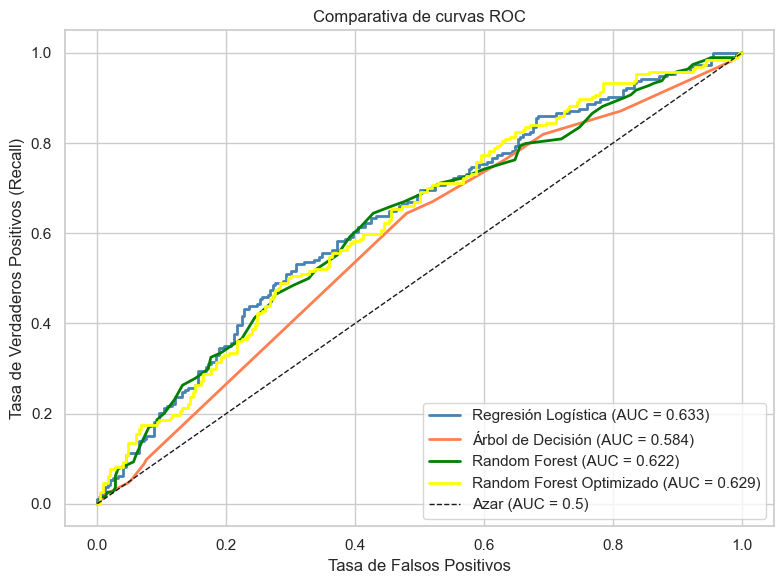

✅ Gráfica guardada


In [27]:
# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(8, 6))

modelos = [
    ('Regresión Logística', y_prob_lr, 'steelblue'),
    ('Árbol de Decisión',   y_prob_dt, 'coral'),
    ('Random Forest',       y_prob_rf, 'green'),
    ('Random Forest Optimizado', y_prob_rf_opt, 'yellow')
]

for nombre, y_prob, color in modelos:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC = {auc:.3f})')

ax.plot([0,1], [0,1], 'k--', lw=1, label='Azar (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax.set_title('Comparativa de curvas ROC')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(ruta + "graf_roc_comparativa_optimizacion.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada")


# 10. Análisis de Umbrales de Clasificación

### ¿Qué es el umbral de clasificación?

Los clasificadores probabilísticos como la **Regresión Logística**, los **Árboles de Decisión** y el **Random Forest** no producen directamente una etiqueta de clase (`Lenta` / `Rápida`), sino una **probabilidad estimada** $\hat{p}_i \in [0, 1]$ de que el paciente $i$ pertenezca a la clase positiva (en nuestro caso, progresión *Rápida*).

La conversión de probabilidad a etiqueta binaria requiere fijar un **umbral de decisión** $\tau$:

$$\hat{y}_i = \begin{cases} 1 \text{ (Rápida)} & \text{si } \hat{p}_i \geq \tau \\ 0 \text{ (Lenta)} & \text{si } \hat{p}_i < \tau \end{cases}$$

Por defecto, **scikit-learn usa $\tau = 0.5$**, pero esto es una convención arbitraria, no una elección clínica.

---

### Por qué el umbral por defecto es inadecuado en contextos clínicos

El umbral $\tau = 0.5$ es óptimo únicamente bajo supuestos muy restrictivos:

1. **Clases perfectamente balanceadas** → No es nuestro caso.
2. **Coste simétrico de errores** → En ELA, **los errores no tienen el mismo coste clínico**:

| Error | Descripción | Consecuencia clínica |
|---|---|---|
| **Falso Negativo (FN)** | Predecir progresión *Lenta* en paciente *Rápida* | ❌ Gravísimo: el paciente no recibe intervención precoz, se pierde ventana terapéutica |
| **Falso Positivo (FP)** | Predecir progresión *Rápida* en paciente *Lenta* | ⚠️ Menos grave: sobretratamiento, estrés innecesario, coste adicional |

En enfermedades progresivas e irreversibles como la ELA, el principio de precaución clínica sugiere **priorizar la Sensibilidad (Recall de la clase Rápida)** aun a costa de reducir la Especificidad.

---

### El trade-off Sensibilidad / Especificidad

Al variar $\tau$, observamos el siguiente comportamiento inverso:

| $\tau$ decrece | $\tau$ aumenta |
|---|---|
| ↑ Sensibilidad (menos FN) | ↑ Especificidad (menos FP) |
| ↓ Especificidad (más FP) | ↓ Sensibilidad (más FN) |
| Modelo más "alarmista" | Modelo más "conservador" |

Este trade-off queda perfectamente visualizado en la **Curva ROC**, que representa todos los pares (Especificidad, Sensibilidad) posibles al variar $\tau \in [0, 1]$.

---

### Métricas para seleccionar el umbral óptimo

Existen varios criterios formales para elegir $\tau^*$:

**a) Índice de Youden (J)**
$$J = \text{Sensibilidad} + \text{Especificidad} - 1$$
Maximiza la suma de ambas métricas de forma balanceada. Corresponde al punto de la curva ROC más alejado de la diagonal.

**b) Maximización del F1-Score**
$$F_1 = 2 \cdot \frac{\text{Precisión} \times \text{Recall}}{\text{Precisión} + \text{Recall}}$$
Equilibra precisión y recall. Útil cuando las clases están desbalanceadas.

**c) Criterio clínico de mínimos Falsos Negativos**
$$\tau^* = \arg\min_{\tau} FN(\tau) \quad \text{sujeto a } \text{Especificidad} \geq \epsilon$$
Directamente orientado a no perder pacientes de riesgo alto, con una cota mínima de especificidad tolerable.

**d) Curva Precision-Recall (PR)**
Especialmente informativa con clases desbalanceadas: muestra el compromiso entre Precisión y Recall al variar el umbral, sin verse distorsionada por la abundancia de verdaderos negativos.

---

### Implicaciones para nuestro sistema de ayuda a la decisión

En el contexto de este trabajo, la selección del umbral óptimo no es un ejercicio técnico menor: **es una decisión clínica** que debe involucrar a los profesionales sanitarios. El modelo puede ofrecer distintos perfiles de riesgo según el umbral elegido:

- **Umbral bajo (ej. 0.30)**: Herramienta de *screening* — detecta casi todos los casos de progresión rápida, útil en consultas iniciales.
- **Umbral alto (ej. 0.70)**: Herramienta de *confirmación* — alta certeza cuando predice Rápida, útil para decisiones terapéuticas agresivas.

El análisis siguiente explora sistemáticamente el comportamiento del **Random Forest optimizado** en todo el espacio de umbrales.


### 10.1 Preparación — probabilidades predichas y umbral base

In [28]:
# Aseguramos reproducibilidad
np.random.seed(11)


# Probabilidades predichas por el Random Forest optimizado
y_prob  = rf_opt.predict_proba(X_test)[:, 1]   # P(Rápida)
y_pred_default = rf_opt.predict(X_test)         # umbral 0.5 por defecto

print("✅ Probabilidades obtenidas")
print(f"   Rango: [{y_prob.min():.3f}, {y_prob.max():.3f}]")
print(f"   Media: {y_prob.mean():.3f}  |  Mediana: {np.median(y_prob):.3f}")
print(f"   Muestras test: {len(y_test)} (Lenta: {(y_test==0).sum()}, Rápida: {(y_test==1).sum()})")

✅ Probabilidades obtenidas
   Rango: [0.090, 0.752]
   Media: 0.442  |  Mediana: 0.442
   Muestras test: 444 (Lenta: 250, Rápida: 194)


### 10.2 Distribución de probabilidades predichas

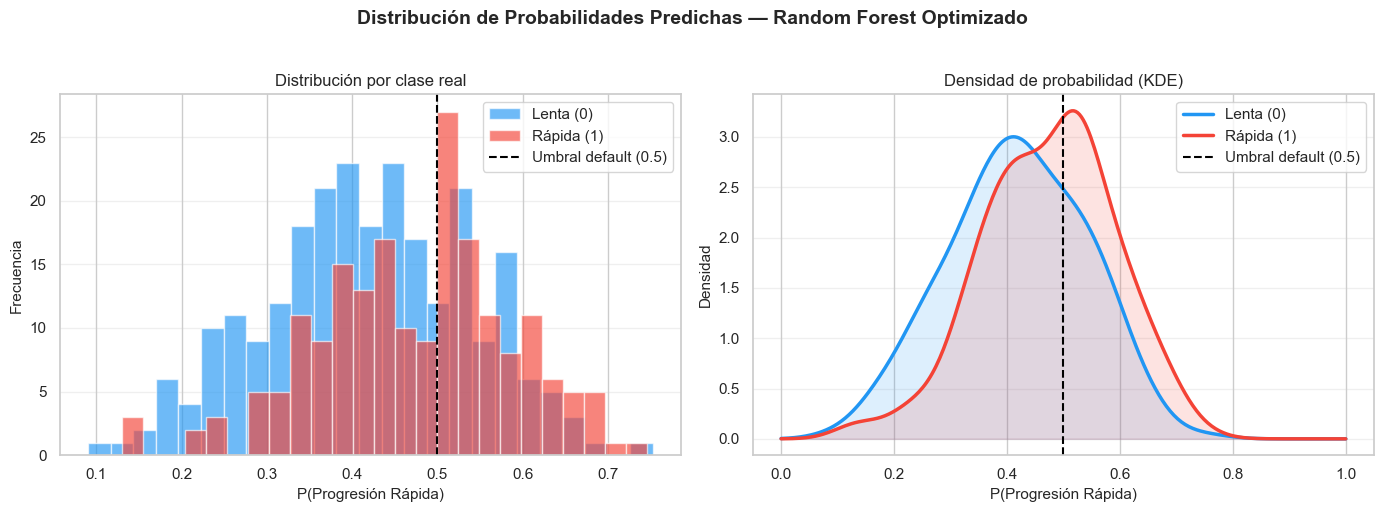


📊 Interpretación:
   Si las distribuciones se solapan mucho → el modelo no separa bien las clases.
   Si están bien separadas → existe un umbral que discrimina eficientemente.


In [29]:
# ============================================================
# CELDA 10.2 — Distribución de probabilidades predichas
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Probabilidades Predichas — Random Forest Optimizado',
             fontsize=14, fontweight='bold', y=1.02)

colores = {'Lenta (0)': '#2196F3', 'Rápida (1)': '#F44336'}

# ── Izquierda: histograma por clase real ──
ax = axes[0]
for label, color, nombre in zip([0, 1], ['#2196F3', '#F44336'], ['Lenta (0)', 'Rápida (1)']):
    mask = (y_test == label)
    ax.hist(y_prob[mask], bins=25, alpha=0.65, color=color, label=nombre, edgecolor='white')

ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Umbral default (0.5)')
ax.set_xlabel('P(Progresión Rápida)', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_title('Distribución por clase real')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# ── Derecha: KDE por clase real ──
ax2 = axes[1]
from scipy.stats import gaussian_kde
x_range = np.linspace(0, 1, 300)

for label, color, nombre in zip([0, 1], ['#2196F3', '#F44336'], ['Lenta (0)', 'Rápida (1)']):
    mask = (y_test == label)
    probs_clase = y_prob[mask]
    if len(probs_clase) > 1:
        kde = gaussian_kde(probs_clase)
        ax2.plot(x_range, kde(x_range), color=color, linewidth=2.5, label=nombre)
        ax2.fill_between(x_range, kde(x_range), alpha=0.15, color=color)

ax2.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Umbral default (0.5)')
ax2.set_xlabel('P(Progresión Rápida)', fontsize=11)
ax2.set_ylabel('Densidad', fontsize=11)
ax2.set_title('Densidad de probabilidad (KDE)')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ruta + "graf_distrib_prob_rf_opt.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Interpretación:")
print("   Si las distribuciones se solapan mucho → el modelo no separa bien las clases.")
print("   Si están bien separadas → existe un umbral que discrimina eficientemente.")

### 10.3 Curva ROC con punto óptimo — Índice de Youden

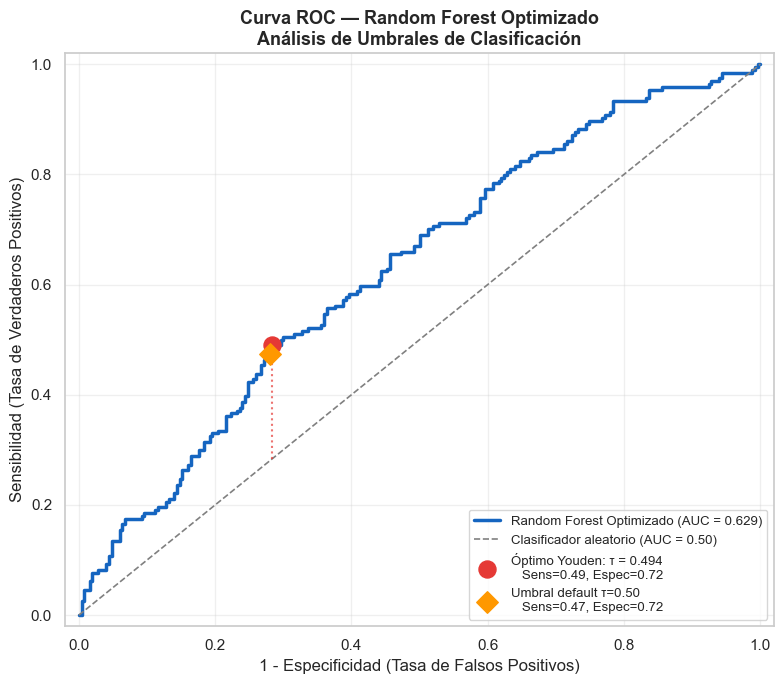


📌 Umbral óptimo (Índice de Youden): τ* = 0.494
   Sensibilidad:   0.490
   Especificidad:  0.716
   Índice J:       0.206


In [30]:
# ============================================================
# CELDA 10.3 — Curva ROC con punto óptimo (Índice de Youden)
# ============================================================

# Cálculo de la curva ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Índice de Youden: J = Sensibilidad + Especificidad - 1 = TPR + (1-FPR) - 1 = TPR - FPR
youden_idx  = np.argmax(tpr - fpr)
tau_youden  = thresholds_roc[youden_idx]
tpr_youden  = tpr[youden_idx]
fpr_youden  = fpr[youden_idx]
especif_youden = 1 - fpr_youden

# Punto umbral 0.5 en la curva ROC
idx_05 = np.argmin(np.abs(thresholds_roc - 0.5))

fig, ax = plt.subplots(figsize=(8, 7))

# Curva ROC
ax.plot(fpr, tpr, color='#1565C0', linewidth=2.5,
        label=f'Random Forest Optimizado (AUC = {auc_score:.3f})')

# Diagonal de referencia (clasificador aleatorio)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.2, label='Clasificador aleatorio (AUC = 0.50)')

# Punto óptimo Youden
ax.scatter(fpr_youden, tpr_youden, color='#E53935', s=150, zorder=5,
           label=f'Óptimo Youden: τ = {tau_youden:.3f}\n   Sens={tpr_youden:.2f}, Espec={especif_youden:.2f}')

# Punto umbral 0.5
ax.scatter(fpr[idx_05], tpr[idx_05], color='#FF9800', s=120, marker='D', zorder=5,
           label=f'Umbral default τ=0.50\n   Sens={tpr[idx_05]:.2f}, Espec={1-fpr[idx_05]:.2f}')

# Línea vertical desde el punto Youden a la diagonal (distancia)
ax.plot([fpr_youden, fpr_youden], [fpr_youden, tpr_youden],
        color='#E53935', linestyle=':', linewidth=1.5, alpha=0.7)

ax.set_xlabel('1 - Especificidad (Tasa de Falsos Positivos)', fontsize=12)
ax.set_ylabel('Sensibilidad (Tasa de Verdaderos Positivos)', fontsize=12)
ax.set_title('Curva ROC — Random Forest Optimizado\nAnálisis de Umbrales de Clasificación', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9.5)
ax.grid(alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig(ruta + "graf_umbrales_rf_optimizado.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📌 Umbral óptimo (Índice de Youden): τ* = {tau_youden:.3f}")
print(f"   Sensibilidad:   {tpr_youden:.3f}")
print(f"   Especificidad:  {especif_youden:.3f}")
print(f"   Índice J:       {tpr_youden - fpr_youden:.3f}")

### 10.4 Curva Precision-Recall

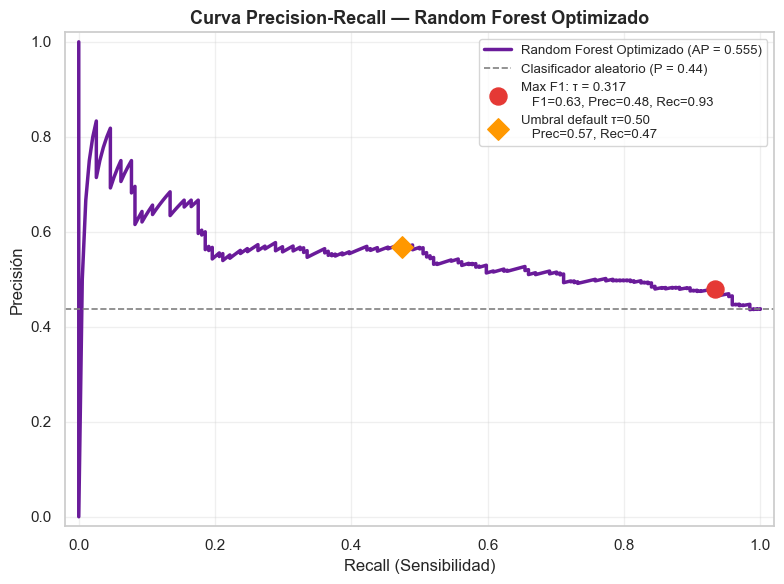


📌 Umbral óptimo (máximo F1):  τ* = 0.317
   Precisión:  0.480
   Recall:     0.933
   F1-Score:   0.634


In [31]:
# ============================================================
# CELDA 10.4 — Curva Precision-Recall
# ============================================================

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

# F1 por umbral (evitamos división por cero)
f1_vals = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) > 0,
    2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),
    0
)
idx_f1_max   = np.argmax(f1_vals)
tau_f1       = thresholds_pr[idx_f1_max]
prec_f1      = precision_vals[idx_f1_max]
rec_f1       = recall_vals[idx_f1_max]

# Punto umbral 0.5
idx_05_pr = np.argmin(np.abs(thresholds_pr - 0.5))

# Prevalencia de la clase positiva (línea de referencia)
prevalencia = (y_test == 1).mean()

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(recall_vals, precision_vals, color='#6A1B9A', linewidth=2.5,
        label=f'Random Forest Optimizado (AP = {avg_precision:.3f})')

ax.axhline(prevalencia, color='gray', linestyle='--', linewidth=1.2,
           label=f'Clasificador aleatorio (P = {prevalencia:.2f})')

# Punto máximo F1
ax.scatter(rec_f1, prec_f1, color='#E53935', s=150, zorder=5,
           label=f'Max F1: τ = {tau_f1:.3f}\n   F1={f1_vals[idx_f1_max]:.2f}, Prec={prec_f1:.2f}, Rec={rec_f1:.2f}')

# Punto umbral 0.5
ax.scatter(recall_vals[idx_05_pr], precision_vals[idx_05_pr],
           color='#FF9800', s=120, marker='D', zorder=5,
           label=f'Umbral default τ=0.50\n   Prec={precision_vals[idx_05_pr]:.2f}, Rec={recall_vals[idx_05_pr]:.2f}')

ax.set_xlabel('Recall (Sensibilidad)', fontsize=12)
ax.set_ylabel('Precisión', fontsize=12)
ax.set_title('Curva Precision-Recall — Random Forest Optimizado', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9.5)
ax.grid(alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig(ruta + "graf_precision_recall_optimizacion.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📌 Umbral óptimo (máximo F1):  τ* = {tau_f1:.3f}")
print(f"   Precisión:  {prec_f1:.3f}")
print(f"   Recall:     {rec_f1:.3f}")
print(f"   F1-Score:   {f1_vals[idx_f1_max]:.3f}")

### 10.5 Evolución de métricas al variar el umbral τ

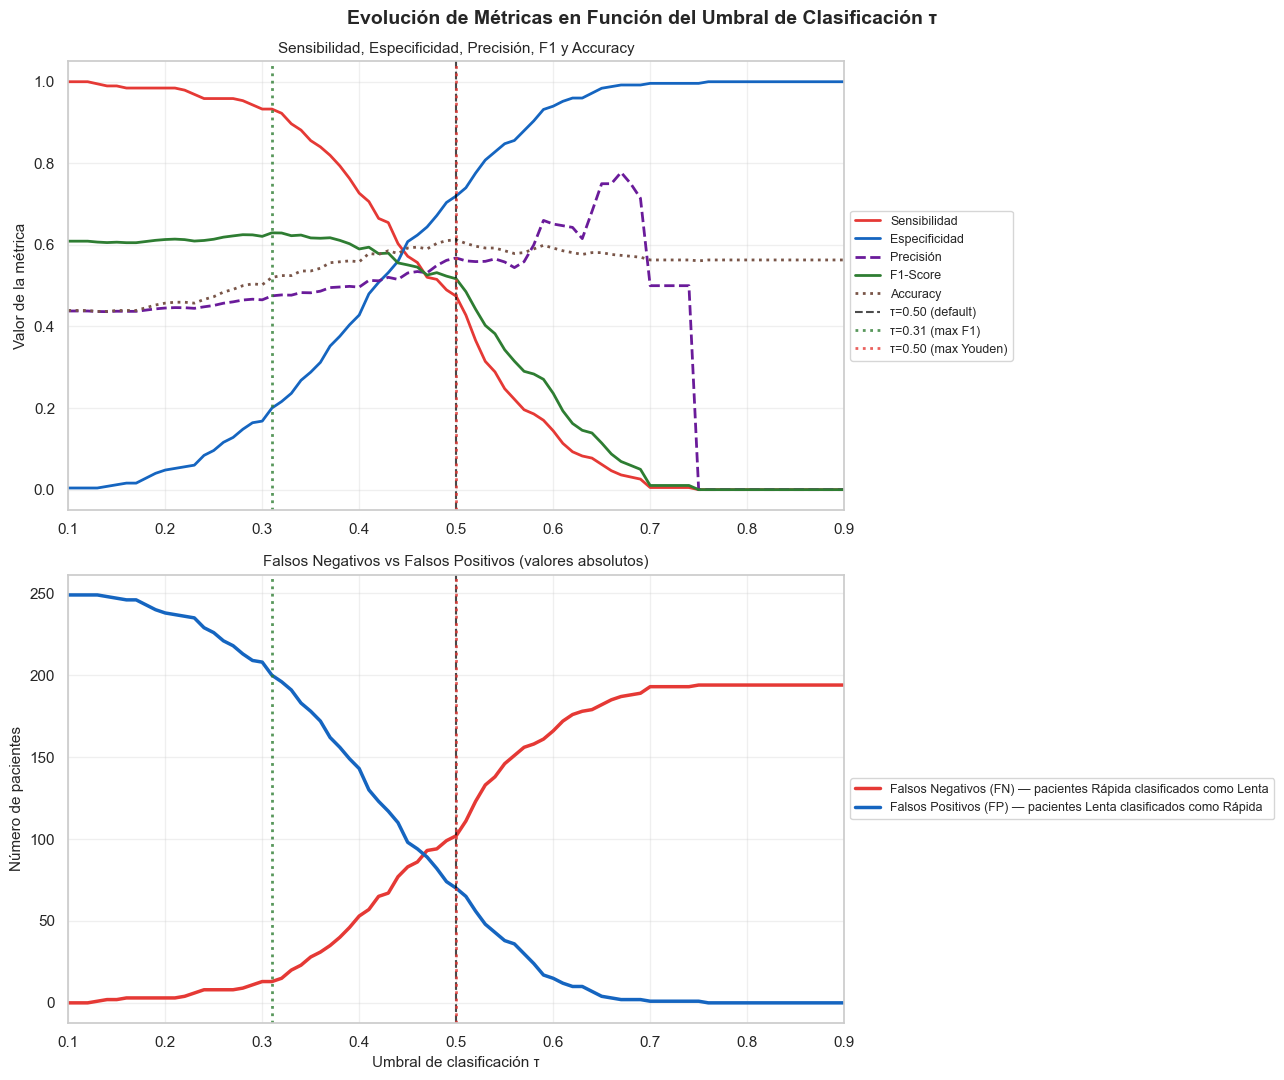


📊 Resumen de umbrales óptimos encontrados:
   τ óptimo (max F1-Score):    0.31
   τ óptimo (max Youden J):    0.50


In [32]:
# ============================================================
# CELDA 10.5 — Evolución de métricas al variar el umbral τ
# ============================================================

umbrales = np.arange(0.10, 0.91, 0.01)

resultados = []
for tau in umbrales:
    y_pred_tau = (y_prob >= tau).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_tau, labels=[0, 1]).ravel()
    
    sensibilidad  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision_    = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1_           = (2 * precision_ * sensibilidad / (precision_ + sensibilidad)
                     if (precision_ + sensibilidad) > 0 else 0.0)
    accuracy_     = (tp + tn) / len(y_test)
    youden_       = sensibilidad + especificidad - 1
    
    resultados.append({
        'umbral': tau,
        'Sensibilidad':  sensibilidad,
        'Especificidad': especificidad,
        'Precisión':     precision_,
        'F1-Score':      f1_,
        'Accuracy':      accuracy_,
        'Youden_J':      youden_,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
    })

df_umbrales = pd.DataFrame(resultados)

# ── Visualización ──
fig, axes = plt.subplots(2, 1, figsize=(13, 11))
fig.suptitle('Evolución de Métricas en Función del Umbral de Clasificación τ',
             fontsize=14, fontweight='bold')

# Gráfico superior: métricas principales
ax1 = axes[0]
metricas_colores = {
    'Sensibilidad':  ('#E53935', '-'),
    'Especificidad': ('#1565C0', '-'),
    'Precisión':     ('#6A1B9A', '--'),
    'F1-Score':      ('#2E7D32', '-'),
    'Accuracy':      ('#795548', ':')
}

for metrica, (color, ls) in metricas_colores.items():
    ax1.plot(df_umbrales['umbral'], df_umbrales[metrica],
             color=color, linestyle=ls, linewidth=2, label=metrica)

# Líneas verticales de umbrales relevantes
tau_best_f1     = df_umbrales.loc[df_umbrales['F1-Score'].idxmax(), 'umbral']
tau_best_youden = df_umbrales.loc[df_umbrales['Youden_J'].idxmax(), 'umbral']

ax1.axvline(0.5,             color='black',  linestyle='--', linewidth=1.5, alpha=0.7, label='τ=0.50 (default)')
ax1.axvline(tau_best_f1,     color='#2E7D32', linestyle=':',  linewidth=2,   alpha=0.8, label=f'τ={tau_best_f1:.2f} (max F1)')
ax1.axvline(tau_best_youden, color='#E53935', linestyle=':',  linewidth=2,   alpha=0.8, label=f'τ={tau_best_youden:.2f} (max Youden)')

ax1.set_ylabel('Valor de la métrica', fontsize=11)
ax1.set_title('Sensibilidad, Especificidad, Precisión, F1 y Accuracy', fontsize=11)
ax1.legend(loc='center left', fontsize=9, bbox_to_anchor=(1, 0.5))
ax1.grid(alpha=0.3)
ax1.set_xlim([0.10, 0.90])
ax1.set_ylim([-0.05, 1.05])

# Gráfico inferior: FP y FN absolutos
ax2 = axes[1]
ax2.plot(df_umbrales['umbral'], df_umbrales['FN'], color='#E53935', linewidth=2.5,
         label='Falsos Negativos (FN) — pacientes Rápida clasificados como Lenta')
ax2.plot(df_umbrales['umbral'], df_umbrales['FP'], color='#1565C0', linewidth=2.5,
         label='Falsos Positivos (FP) — pacientes Lenta clasificados como Rápida')

ax2.axvline(0.5,             color='black',  linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axvline(tau_best_f1,     color='#2E7D32', linestyle=':',  linewidth=2,   alpha=0.8)
ax2.axvline(tau_best_youden, color='#E53935', linestyle=':',  linewidth=2,   alpha=0.8)

ax2.set_xlabel('Umbral de clasificación τ', fontsize=11)
ax2.set_ylabel('Número de pacientes', fontsize=11)
ax2.set_title('Falsos Negativos vs Falsos Positivos (valores absolutos)', fontsize=11)
ax2.legend(loc='center left', fontsize=9, bbox_to_anchor=(1, 0.5))
ax2.grid(alpha=0.3)
ax2.set_xlim([0.10, 0.90])

plt.tight_layout()
plt.savefig(ruta + "graf_metricas_enfuncionde_umbral.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Resumen de umbrales óptimos encontrados:")
print(f"   τ óptimo (max F1-Score):    {tau_best_f1:.2f}")
print(f"   τ óptimo (max Youden J):    {tau_best_youden:.2f}")

### 10.6 Matrices de confusión para cinco umbrales clave

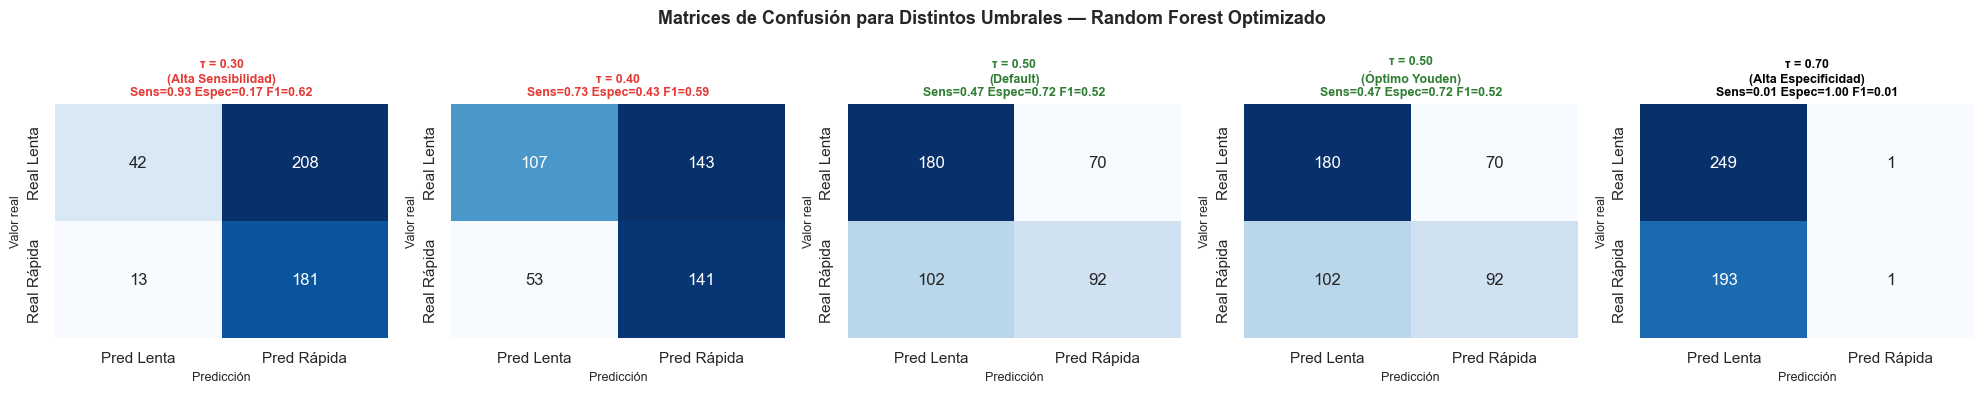


🔍 Observaciones clínicas:
   τ=0.30 → Mínimos FN (no perdemos pacientes de progresión rápida), pero más FP
   τ=0.50 → Comportamiento por defecto, equilibrio convencional
   τ=0.50 → Mejor balance matemático Sensibilidad/Especificidad
   τ=0.70 → Máxima especificidad, pero muchos FN (riesgo clínico elevado)


In [33]:
# ============================================================
# CELDA 10.6 — Matrices de confusión para 5 umbrales clave
# ============================================================

umbrales_clave = {
    'τ = 0.30\n(Alta Sensibilidad)': 0.30,
    'τ = 0.40':                      0.40,
    'τ = 0.50\n(Default)':           0.50,
    f'τ = {tau_best_youden:.2f}\n(Óptimo Youden)': tau_best_youden,
    'τ = 0.70\n(Alta Especificidad)': 0.70
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Matrices de Confusión para Distintos Umbrales — Random Forest Optimizado',
             fontsize=13, fontweight='bold')

for ax, (titulo, tau) in zip(axes, umbrales_clave.items()):
    y_pred_tau = (y_prob >= tau).astype(int)
    cm = confusion_matrix(y_test, y_pred_tau, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1   = f1_score(y_test, y_pred_tau, zero_division=0)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Lenta', 'Pred Rápida'],
                yticklabels=['Real Lenta', 'Real Rápida'],
                cbar=False, annot_kws={'size': 12})
    
    color_titulo = '#E53935' if tau < 0.45 else ('#2E7D32' if abs(tau - tau_best_youden) < 0.01 else 'black')
    ax.set_title(f'{titulo}\nSens={sens:.2f} Espec={spec:.2f} F1={f1:.2f}',
                 fontsize=9, color=color_titulo, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=9)
    ax.set_ylabel('Valor real', fontsize=9)

plt.tight_layout()
plt.savefig(ruta + "graf_matriz_conf_umbrales.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Observaciones clínicas:")
print("   τ=0.30 → Mínimos FN (no perdemos pacientes de progresión rápida), pero más FP")
print("   τ=0.50 → Comportamiento por defecto, equilibrio convencional")
print(f"   τ={tau_best_youden:.2f} → Mejor balance matemático Sensibilidad/Especificidad")
print("   τ=0.70 → Máxima especificidad, pero muchos FN (riesgo clínico elevado)")

### 10.7 Tabla resumen comparativa de umbrales

In [34]:
# ============================================================
# CELDA 10.7 — Tabla resumen comparativa de umbrales
# ============================================================

umbrales_tabla = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, tau_best_youden,
                  tau_best_f1, 0.60, 0.65, 0.70, 0.75, 0.80]
umbrales_tabla = sorted(set([round(u, 2) for u in umbrales_tabla]))

filas = []
for tau in umbrales_tabla:
    fila = df_umbrales.iloc[(df_umbrales['umbral'] - tau).abs().argsort()[:1]]
    filas.append(fila)

df_tabla = pd.concat(filas).drop_duplicates('umbral').reset_index(drop=True)
df_tabla_show = df_tabla[['umbral','Sensibilidad','Especificidad','Precisión','F1-Score','Accuracy','FN','FP']].copy()

# Formato numérico
for col in ['Sensibilidad','Especificidad','Precisión','F1-Score','Accuracy']:
    df_tabla_show[col] = df_tabla_show[col].map(lambda x: f'{x:.3f}')

# Marcar filas especiales
def marca(row):
    tau = row['umbral']
    if abs(tau - 0.50) < 0.005:
        return ['background-color: #FFF9C4'] * len(row)   # amarillo (default)
    elif abs(tau - tau_best_youden) < 0.005:
        return ['background-color: #C8E6C9'] * len(row)   # verde (Youden)
    elif abs(tau - tau_best_f1) < 0.005:
        return ['background-color: #BBDEFB'] * len(row)   # azul (max F1)
    return [''] * len(row)

print("=" * 80)
print("   TABLA COMPARATIVA DE UMBRALES — Random Forest Optimizado")
print("=" * 80)
print(f"   {'τ':>6}  {'Sensib':>8}  {'Especif':>8}  {'Precisión':>9}  {'F1':>7}  {'Acc':>7}  {'FN':>4}  {'FP':>4}")
print("-" * 80)
for _, row in df_tabla_show.iterrows():
    marcador = ""
    if abs(float(row['umbral']) - 0.50) < 0.005:           marcador = " ◄ default"
    if abs(float(row['umbral']) - tau_best_youden) < 0.005: marcador = " ★ óptimo Youden"
    if abs(float(row['umbral']) - tau_best_f1) < 0.005:    marcador = " ✦ óptimo F1"
    print(f"   {row['umbral']:>6.2f}  {row['Sensibilidad']:>8}  {row['Especificidad']:>8}  "
          f"{row['Precisión']:>9}  {row['F1-Score']:>7}  {row['Accuracy']:>7}  "
          f"{int(row['FN']):>4}  {int(row['FP']):>4}{marcador}")
print("=" * 80)
print("   ◄ default | ★ máximo Youden J | ✦ máximo F1-Score")

   TABLA COMPARATIVA DE UMBRALES — Random Forest Optimizado
        τ    Sensib   Especif  Precisión       F1      Acc    FN    FP
--------------------------------------------------------------------------------
     0.20     0.985     0.048      0.445    0.613    0.457     3   238
     0.25     0.959     0.096      0.451    0.614    0.473     8   226
     0.30     0.933     0.168      0.465    0.621    0.502    13   208
     0.31     0.933     0.200      0.475    0.630    0.520    13   200 ✦ óptimo F1
     0.35     0.856     0.288      0.483    0.617    0.536    28   178
     0.40     0.727     0.428      0.496    0.590    0.559    53   143
     0.45     0.572     0.608      0.531    0.551    0.592    83    98
     0.50     0.474     0.720      0.568    0.517    0.613   102    70 ★ óptimo Youden
     0.55     0.247     0.848      0.558    0.343    0.586   146    38
     0.60     0.144     0.940      0.651    0.236    0.592   166    15
     0.65     0.062     0.984      0.750    0.114 


## Discusión y Recomendación Clínica del Umbral

El análisis de umbrales revela que la elección de $\tau = 0.5$ **no es la más adecuada para un sistema de apoyo a la decisión clínica en ELA**. Los resultados cuantitativos obtenidos permiten identificar tres perfiles de uso diferenciados:

| Perfil | Umbral recomendado | Uso clínico sugerido | Trade-off |
|---|---|---|---|
| **Screening / Cribado** | $\tau \approx 0.30$ | Primera consulta de sospecha diagnóstica; no perder ningún paciente de alto riesgo | ↑ FP, ↓ FN |
| **Equilibrado** | $\tau^*$ (Youden/F1) | Seguimiento periódico con recursos moderados | Balance óptimo |
| **Confirmación** | $\tau \approx 0.65-0.70$ | Decisión de intervención terapéutica agresiva o ensayo clínico | ↓ FP, ↑ FN |

### Limitaciones a considerar

1. **AUC-ROC = 0.629**: El poder discriminativo del modelo es **moderado-bajo**. Un AUC cercano a 0.63 indica que el modelo supera al azar, pero la separación entre clases es insuficiente para uso clínico autónomo. Cualquier umbral que seleccionemos operará sobre probabilidades con alta incertidumbre.

2. **Calibración**: Antes de aplicar el umbral en la práctica, sería necesario verificar que las probabilidades predichas estén **bien calibradas** (es decir, que un paciente con $\hat{p} = 0.7$ tenga realmente ~70% de probabilidad de progresión rápida). Esto se puede evaluar con curvas de calibración (*reliability diagrams*).

3. **Validación externa**: El umbral óptimo calculado sobre el conjunto de test puede no generalizarse a otras cohortes de pacientes con ELA. Se recomienda validación en datos independientes.


---
> **El análisis de umbrales no modifica las limitaciones intrínsecas del modelo (AUC ≈ 0.63), pero permite extraer el máximo valor clínico posible de la información probabilística disponible.** En un sistema de ayuda a la decisión, este análisis debería presentarse al clínico como un panel interactivo donde, en función del contexto (primera visita vs. revisión vs. decisión terapéutica), se pueda seleccionar el umbral más apropiado.


---
# 11. Curvas de Aprendizaje — ¿Necesitamos más datos?

---

## ¿Qué es una curva de aprendizaje?

Una **curva de aprendizaje** (*learning curve*) mide cómo evoluciona el rendimiento de un modelo a medida que aumenta el tamaño del conjunto de entrenamiento. La idea central es sencilla: entrenamos el mismo modelo repetidas veces, cada vez con una fracción mayor de los datos disponibles, y registramos su rendimiento tanto en entrenamiento como en validación.

Formalmente, dado un conjunto de entrenamiento $\mathcal{D}_{train}$ de tamaño $N$, definimos una secuencia de subconjuntos anidados:
$$\mathcal{D}_1 \subset \mathcal{D}_2 \subset \cdots \subset \mathcal{D}_K = \mathcal{D}_{train}, \quad |\mathcal{D}_k| = n_k$$

Para cada $n_k$, calculamos:
- $\text{Score}_{train}(n_k)$: rendimiento sobre el propio subconjunto de entrenamiento.
- $\text{Score}_{val}(n_k)$: rendimiento mediante validación cruzada sobre datos no vistos.

La **brecha** entre ambas curvas y su evolución al crecer $n_k$ nos permite diagnosticar el problema fundamental del modelo.

---
## Diagnóstico: los tres patrones posibles

El aspecto de las curvas de aprendizaje permite identificar tres situaciones clínicas distintas para el modelo:

### Patrón 1 — Alto sesgo (*Underfitting*)
```
Score
  1.0 |                         
  0.8 |────────────── train (baja)
  0.6 |─────────────── val  (baja, similar a train)
  0.4 |___________________________
        pocos datos     muchos datos → n
```
- Ambas curvas convergen a un valor **bajo**.
- La brecha entre train y val es **pequeña**.
- **Diagnóstico**: el modelo es demasiado simple para capturar la complejidad del problema. Más datos **no ayudarán**, necesitamos un modelo más complejo o mejores *features*.

### Patrón 2 — Alta varianza (*Overfitting*)
```
Score
  1.0 |──────── train (muy alta)
  0.8 |
  0.6 |              ╱── val (sigue subiendo)
  0.4 |___________________________
        pocos datos     muchos datos → n
```
- La curva de entrenamiento es **alta**, la de validación es **baja**.
- La brecha es **grande** y persiste.
- La curva de validación **sigue subiendo** al añadir datos.
- **Diagnóstico**: el modelo memoriza en lugar de generalizar. Más datos **sí ayudarían**, o podemos regularizar más.

### Patrón 3 — Buen ajuste (*Well-fitted*)
```
Score
  1.0 |
  0.8 |──── train ╲
  0.7 |            ╲══════ convergen aquí
  0.6 |         ╱ val
  0.4 |___________________________
        pocos datos     muchos datos → n
```
- Ambas curvas **convergen** a un valor razonablemente alto.
- La brecha es **pequeña** con muchos datos.
- **Diagnóstico**: el modelo ha aprendido bien. Más datos ayudan poco — mejor buscar mejores *features*.

---
## Relevancia específica para nuestro problema ELA

En el contexto de este trabajo, la pregunta es especialmente pertinente. Los registros de pacientes con ELA son **escasos por naturaleza**: la enfermedad tiene una prevalencia de ~5-7 casos por 100.000 habitantes, los seguimientos longitudinales son costosos, y la mortalidad limita la duración del estudio.

Nuestros modelos han obtenido un AUC-ROC en torno a **0.63**, que es modesto. Antes de concluir que el problema es inherentemente difícil de predecir, conviene responder:

> *¿Es el rendimiento bajo porque el modelo no tiene suficientes ejemplos para aprender, o porque el problema es intrínsecamente ruidoso con los predictores disponibles?*

Las curvas de aprendizaje son la herramienta estadística adecuada para responder esta pregunta de forma empírica, sin conjeturas.

Usaremos el **Random Forest optimizado** como modelo principal, pero también compararemos los tres modelos para ver si el patrón es consistente o específico de cada algoritmo.

In [35]:
# ============================================================
# CELDA 11.1 — Recuperación de modelos
# ============================================================

np.random.seed(11)
# Reconstruimos el dataset completo para la curva de aprendizaje
# (usamos train+test para tener el rango completo de tamaños)
X_full = np.vstack([X_train, X_test])
y_full = np.concatenate([y_train, y_test])

print(f"✅ Dataset completo para curvas de aprendizaje:")
print(f"   Total muestras: {len(y_full)}")
print(f"   Lenta (0): {(y_full==0).sum()} ({(y_full==0).mean()*100:.1f}%)")
print(f"   Rápida (1): {(y_full==1).sum()} ({(y_full==1).mean()*100:.1f}%)")
print(f"   Features:   {X_full.shape[1]}")

✅ Dataset completo para curvas de aprendizaje:
   Total muestras: 2219
   Lenta (0): 1248 (56.2%)
   Rápida (1): 971 (43.8%)
   Features:   20


---
## 11.2 Cálculo de las curvas de aprendizaje

Utilizamos la función `learning_curve` de scikit-learn, que automáticamente:

1. Divide los datos en $k$ folds de validación cruzada estratificada.
2. Para cada tamaño $n_k$ definido, entrena el modelo en un subconjunto de ese tamaño.
3. Evalúa en entrenamiento y en validación, repitiendo $k$ veces para obtener **media y desviación típica** del score.

El intervalo de confianza sombreado en las gráficas representa $\mu \pm \sigma$ de los $k$ folds, lo que permite distinguir variabilidad real de fluctuaciones aleatorias.

Usaremos **AUC-ROC** como métrica, consistente con todo el análisis anterior.

In [36]:
# ============================================================
# CELDA 11.2 — Cálculo de curvas de aprendizaje (los 3 modelos)
# ============================================================

from sklearn.base import clone

# Estrategia de CV: estratificada para respetar el desbalance de clases
cv_strategy = 5   # 5-fold estratificado

# Tamaños de entrenamiento a evaluar (desde 10% hasta 100%)
train_sizes = np.linspace(0.10, 1.0, 15)

modelos_lc = {
    'Regresión Logística': lr,
    'Árbol de Decisión':   dt,
    'Random Forest\nOptimizado': rf_opt
}

resultados_lc = {}

print("Calculando curvas de aprendizaje...")
print("(Esto puede tardar 1-2 minutos)\n")

for nombre, modelo in modelos_lc.items():
    print(f"   ▶ {nombre.replace(chr(10), ' ')}...", end=' ')
    
    train_sz, train_scores, val_scores = learning_curve(
        estimator   = clone(modelo),
        X           = X_full,
        y           = y_full,
        train_sizes = train_sizes,
        cv          = cv_strategy,
        scoring     = 'roc_auc',
        n_jobs      = -1,
        random_state= 11
    )
    
    resultados_lc[nombre] = {
        'train_sizes':   train_sz,
        'train_mean':    train_scores.mean(axis=1),
        'train_std':     train_scores.std(axis=1),
        'val_mean':      val_scores.mean(axis=1),
        'val_std':       val_scores.std(axis=1),
    }
    print(f"✅  (AUC val final: {val_scores.mean(axis=1)[-1]:.3f})")

print("\n✅ Curvas calculadas para los 3 modelos.")

Calculando curvas de aprendizaje...
(Esto puede tardar 1-2 minutos)

   ▶ Regresión Logística... ✅  (AUC val final: 0.637)
   ▶ Árbol de Decisión... ✅  (AUC val final: 0.588)
   ▶ Random Forest Optimizado... ✅  (AUC val final: 0.628)

✅ Curvas calculadas para los 3 modelos.


---
## 11.3 Visualización e interpretación

En los gráficos siguientes, interpretamos cada curva atendiendo a:

- **Línea continua azul** → Score en entrenamiento (↓ con más datos: el modelo ya no memoriza tan bien)
- **Línea continua roja** → Score en validación (↑ con más datos: el modelo generaliza mejor)
- **Banda sombreada** → Intervalo $\mu \pm \sigma$ de los 5 folds
- **Brecha entre curvas** → Si es grande y persistente: *overfitting*; si es pequeña desde el principio: *underfitting*
- **Pendiente de la curva de validación** → Si sigue subiendo al llegar al 100% de datos: más datos ayudarían

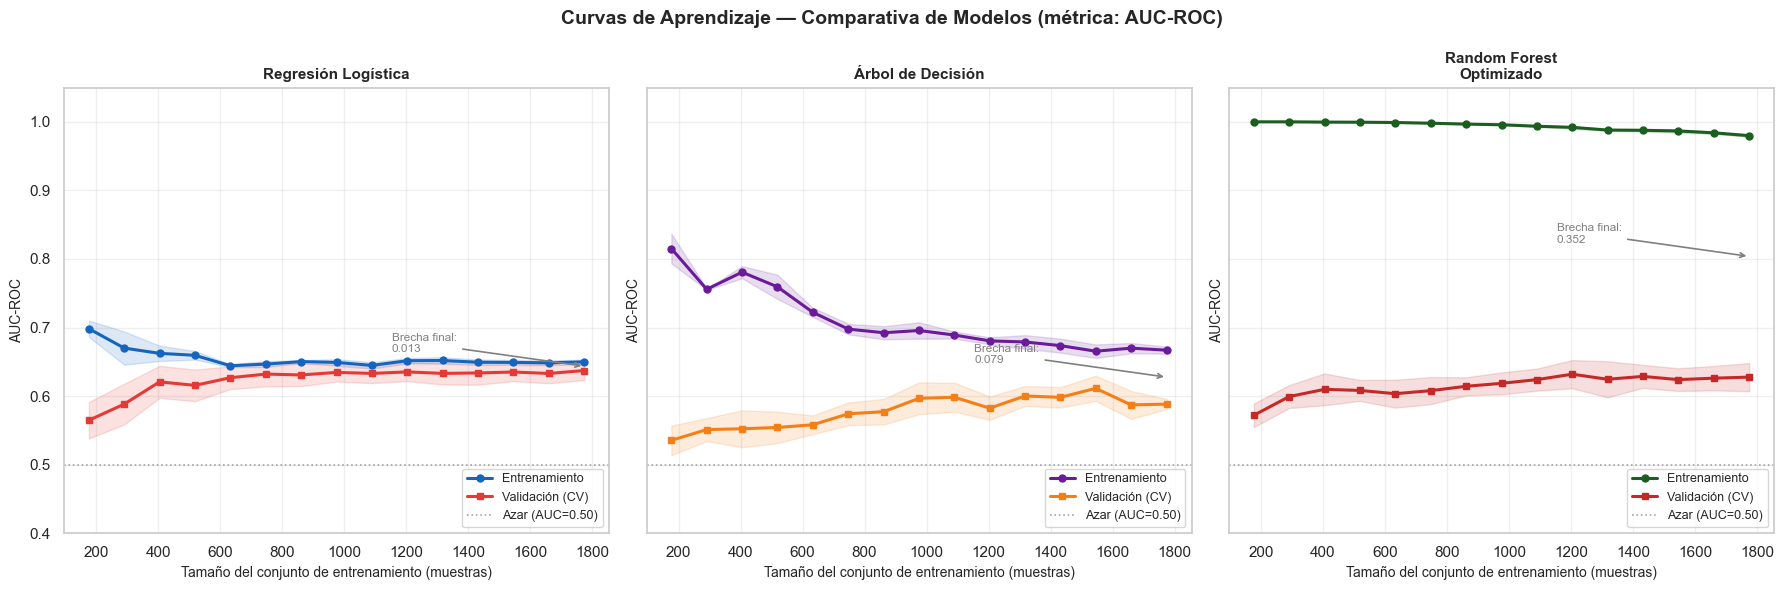

In [37]:
# ============================================================
# CELDA 11.3 — Visualización curvas de aprendizaje (3 modelos)
# ============================================================

colores_modelos = [
    ('#1565C0', '#E53935'),   # Regresión Logística:  azul train, rojo val
    ('#6A1B9A', '#F57F17'),   # Árbol de Decisión:    morado train, naranja val
    ('#1B5E20', '#C62828'),   # Random Forest:        verde train, rojo oscuro val
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Curvas de Aprendizaje — Comparativa de Modelos (métrica: AUC-ROC)',
             fontsize=14, fontweight='bold')

for ax, (nombre, res), (c_train, c_val) in zip(axes, resultados_lc.items(), colores_modelos):
    sz      = res['train_sizes']
    tr_m    = res['train_mean']
    tr_s    = res['train_std']
    va_m    = res['val_mean']
    va_s    = res['val_std']
    
    # Curvas
    ax.plot(sz, tr_m, 'o-', color=c_train, linewidth=2.2, markersize=5, label='Entrenamiento')
    ax.fill_between(sz, tr_m - tr_s, tr_m + tr_s, alpha=0.15, color=c_train)
    
    ax.plot(sz, va_m, 's-', color=c_val, linewidth=2.2, markersize=5, label='Validación (CV)')
    ax.fill_between(sz, va_m - va_s, va_m + va_s, alpha=0.15, color=c_val)
    
    # Línea de referencia AUC=0.5
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.7, label='Azar (AUC=0.50)')
    
    # Brecha final
    brecha = tr_m[-1] - va_m[-1]
    ax.annotate(f'Brecha final:\n{brecha:.3f}',
                xy=(sz[-1], (tr_m[-1] + va_m[-1]) / 2),
                xytext=(sz[-1] * 0.65, (tr_m[-1] + va_m[-1]) / 2 + 0.02),
                fontsize=8.5, color='gray',
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))
    
    ax.set_title(nombre, fontsize=11, fontweight='bold')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento (muestras)', fontsize=10)
    ax.set_ylabel('AUC-ROC', fontsize=10)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim([0.40, 1.05])

plt.tight_layout()
plt.savefig(ruta + "graf_curvas__apredizaje_comparativa_optimizacion.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 11.4 Análisis de la brecha y la pendiente de convergencia

Además de observar cualitativamente las curvas, podemos cuantificar dos indicadores clave:

**a) Brecha relativa** entre curvas de entrenamiento y validación al 100% de datos:
$$\text{Brecha} = \text{AUC}_{train}(N) - \text{AUC}_{val}(N)$$
- Brecha **grande** (> 0.10) → sobreajuste, más datos o más regularización.
- Brecha **pequeña** (< 0.05) con AUC bajo → sesgo, el modelo no captura el patrón.

**b) Pendiente de la curva de validación** en el tramo final:
$$\Delta_{val} = \text{AUC}_{val}(N) - \text{AUC}_{val}(0.75 \cdot N)$$
- Pendiente **positiva y significativa** → la curva no ha plateado, más datos ayudarían.
- Pendiente **cercana a 0** → hemos alcanzado la meseta, más datos no mejorarán sustancialmente el modelo.

In [38]:
# ============================================================
# CELDA 11.4 — Cuantificación: brecha y pendiente de convergencia
# ============================================================

print("=" * 72)
print("   DIAGNÓSTICO CUANTITATIVO — Curvas de Aprendizaje")
print("=" * 72)
print(f"   {'Modelo':<30} {'AUC_train':>10} {'AUC_val':>9} {'Brecha':>8} {'Δ_val (últ. 25%)':>18} {'Diagnóstico':>15}")
print("-" * 72)

for nombre, res in resultados_lc.items():
    auc_train_final = res['train_mean'][-1]
    auc_val_final   = res['val_mean'][-1]
    brecha          = auc_train_final - auc_val_final
    
    # Pendiente en el último 25% de los datos
    n75_idx = int(len(res['val_mean']) * 0.75)
    delta_val = res['val_mean'][-1] - res['val_mean'][n75_idx]
    
    # Diagnóstico automático
    if brecha > 0.10 and delta_val > 0.005:
        diagnostico = "Alta varianza"
    elif brecha > 0.10 and delta_val <= 0.005:
        diagnostico = "Varianza + meseta"
    elif brecha <= 0.07 and auc_val_final < 0.65:
        diagnostico = "Alto sesgo"
    else:
        diagnostico = "Convergiendo"
    
    nombre_corto = nombre.replace('\n', ' ')
    print(f"   {nombre_corto:<30} {auc_train_final:>10.3f} {auc_val_final:>9.3f} "
          f"{brecha:>8.3f} {delta_val:>18.4f} {diagnostico:>15}")

print("=" * 72)
print()
print("   Guía de interpretación:")
print("   Brecha > 0.10 con Δ_val > 0     → Overfitting; más datos o más regularización")
print("   Brecha < 0.07 y AUC_val < 0.65  → Underfitting; modelo/features más complejos")
print("   Δ_val > 0.005 (pendiente activa) → La curva no ha plateado, más datos ayudarían")
print("   Δ_val ≈ 0     (meseta)           → Más datos tendrían poco impacto")

   DIAGNÓSTICO CUANTITATIVO — Curvas de Aprendizaje
   Modelo                          AUC_train   AUC_val   Brecha   Δ_val (últ. 25%)     Diagnóstico
------------------------------------------------------------------------
   Regresión Logística                 0.650     0.637    0.013             0.0035      Alto sesgo
   Árbol de Decisión                   0.667     0.588    0.079            -0.0099    Convergiendo
   Random Forest Optimizado            0.980     0.628    0.352            -0.0011 Varianza + meseta

   Guía de interpretación:
   Brecha > 0.10 con Δ_val > 0     → Overfitting; más datos o más regularización
   Brecha < 0.07 y AUC_val < 0.65  → Underfitting; modelo/features más complejos
   Δ_val > 0.005 (pendiente activa) → La curva no ha plateado, más datos ayudarían
   Δ_val ≈ 0     (meseta)           → Más datos tendrían poco impacto


---
# 12. Análisis de Subgrupos

---

## Justificación del análisis de subgrupos

Un modelo predictivo con AUC global de 0.632 oculta información clínica fundamental: **¿funciona igual de bien para todos los pacientes, o hay subpoblaciones donde predice mejor o peor?**

Esta pregunta no es trivial. En ELA existe evidencia clínica consolidada de que la enfermedad es **biológicamente heterogénea** según el fenotipo de presentación:

- Los pacientes con **inicio bulbar** tienen peor pronóstico y mayor velocidad de progresión media que los de inicio espinal.
- Las **mujeres** presentan con mayor frecuencia inicio bulbar, lo que confunde sexo y sitio de inicio como predictores.
- La **edad avanzada** al diagnóstico se asocia a progresión más rápida en múltiples cohortes.
- Una **FVC basal baja** refleja afectación respiratoria precoz, marcador de progresión rápida.

Si el modelo funciona bien en un subgrupo pero mal en otro, su aplicación clínica indiscriminada sería engañosa, y potencialmente dañina para los pacientes del subgrupo con peor rendimiento.

El análisis de subgrupos que sigue tiene dos objetivos:
1. **Detectar heterogeneidad** en el rendimiento del modelo entre grupos clínicamente relevantes.
2. **Identificar qué perfiles de paciente** se benefician más (o menos) del sistema de apoyo a la decisión.

---
## Definición de los subgrupos

Utilizaremos cinco variables de estratificación, seleccionadas por su relevancia clínica en ELA y su disponibilidad en el dataset:

| Subgrupo | Variable fuente | Grupos | Justificación clínica |
|---|---|---|---|
| **Sexo** | `Sex` | Hombre / Mujer | Diferencias en fenotipo y pronóstico documentadas |
| **Sitio de inicio** | `onset_*` (dummies) | Bulbar / Espinal / Otro | Principal determinante fenotípico de la velocidad de progresión |
| **Edad al diagnóstico** | `Age` | < 65 años / ≥ 65 años | Edad avanzada como factor pronóstico adverso |
| **Función respiratoria basal** | `fvc_basal` | FVC ≥ 80% / FVC < 80% | FVC < 80% indica compromiso respiratorio precoz |
| **Severidad funcional basal** | `alsfrs_basal_total` | ALSFRS ≥ 36 / < 36 | Puntuación < 36 refleja afectación funcional moderada-severa al inicio |

> **Nota metodológica**: El análisis se realiza **siempre sobre el conjunto de test** (`X_test`, `y_test`) para garantizar que evaluamos generalización real, no ajuste a los datos de entrenamiento. Para mantener la trazabilidad, reconstruimos los índices del test en el DataFrame original `df`.

In [39]:
# ============================================================
# CELDA 12.1 — Preparación: reconstruir subgrupos en el test set
# ============================================================

np.random.seed(11)

# ── Recuperamos las filas del test en el DataFrame original ──
# Columnas que necesitamos para los subgrupos
cols_subgrupo = [
    'subject_id', 'Sex', 'Age',
    'alsfrs_basal_total', 'fvc_basal',
    'onset_bulbar', 'onset_limb', 'onset_spine',
    'onset_limb_bulbar', 'onset_other', 'onset_unknown',
    'progresion_rapida'
]

# Recuperamos el índice del test set desde el split original ya que lo almacenamos en idx_test
df_clean = df[cols_subgrupo].dropna(subset=['progresion_rapida'])
df_test_sg = df_clean.loc[idx_test].copy().reset_index(drop=True)

# Añadimos predicciones
df_test_sg['y_true'] = y_test.values
df_test_sg['y_prob'] = y_prob_rf_opt
df_test_sg['y_pred'] = (y_prob_rf_opt >= 0.5).astype(int)

# ── Reconstruimos la variable sitio de inicio a partir de dummies ──
def reconstruir_sitio(row):
    if row['onset_bulbar'] == 1:
        return 'Bulbar'
    elif row['onset_limb'] == 1 or row['onset_spine'] == 1:
        return 'Espinal/Extremidades'
    elif row['onset_limb_bulbar'] == 1:
        return 'Mixto (Bulbar+Extremidades)'
    else:
        return 'Otro/Desconocido'

df_test_sg['sitio_inicio'] = df_test_sg.apply(reconstruir_sitio, axis=1)

# ── Variables dicotómicas adicionales ──
df_test_sg['grupo_edad']   = pd.cut(df_test_sg['Age'],
                                     bins=[0, 64, 200],
                                     labels=['< 65 años', '≥ 65 años'])
df_test_sg['grupo_fvc']    = pd.cut(df_test_sg['fvc_basal'],
                                     bins=[0, 79.9, 200],
                                     labels=['FVC < 80%', 'FVC ≥ 80%'])
df_test_sg['grupo_alsfrs'] = pd.cut(df_test_sg['alsfrs_basal_total'],
                                     bins=[0, 35.9, 100],
                                     labels=['ALSFRS < 36', 'ALSFRS ≥ 36'])

print("✅ DataFrame de test con subgrupos construido")
print(f"   Total pacientes test: {len(df_test_sg)}")
print(f"\n   Distribución por sexo:")
print(df_test_sg['Sex'].value_counts().to_string())
print(f"\n   Distribución por sitio de inicio:")
print(df_test_sg['sitio_inicio'].value_counts().to_string())
print(f"\n   Distribución por grupo de edad:")
print(df_test_sg['grupo_edad'].value_counts().to_string())

✅ DataFrame de test con subgrupos construido
   Total pacientes test: 444

   Distribución por sexo:
Sex
1.0    268
0.0    176

   Distribución por sitio de inicio:
sitio_inicio
Espinal/Extremidades           202
Otro/Desconocido               194
Bulbar                          47
Mixto (Bulbar+Extremidades)      1

   Distribución por grupo de edad:
grupo_edad
< 65 años    367
≥ 65 años     77


---
## 12.2 Función de evaluación por subgrupo

Para cada subgrupo calculamos el mismo conjunto de métricas que hemos usado a lo largo del trabajo, lo que permite comparaciones directas:

- **AUC-ROC**: capacidad discriminativa global del modelo en ese subgrupo.
- **Sensibilidad (Recall clase Rápida)**: proporción de pacientes Rápida correctamente identificados — la métrica clínicamente más crítica.
- **Especificidad**: proporción de pacientes Lenta correctamente identificados.
- **F1-Score**: media armónica de precisión y recall, robusta al desbalance.
- **N**: tamaño del subgrupo, para contextualizar la fiabilidad de las métricas.

⚠️ Los subgrupos pequeños (N < 30) producen estimaciones métricas con alta varianza, sus valores deben interpretarse con cautela.

In [40]:
# ============================================================
# CELDA 12.2 — Función de métricas por subgrupo
# ============================================================

def metricas_subgrupo(df_sub, nombre_subgrupo=''):
    """
    Calcula métricas de clasificación para un subgrupo dado.
    Requiere columnas: y_true, y_prob, y_pred
    """
    n = len(df_sub)
    if n < 10:
        return None  # subgrupo demasiado pequeño
    
    yt = df_sub['y_true'].values
    yp = df_sub['y_prob'].values
    yc = df_sub['y_pred'].values
    
    # AUC solo calculable si hay ambas clases
    if len(np.unique(yt)) < 2:
        auc = np.nan
    else:
        auc = roc_auc_score(yt, yp)
    
    tn, fp, fn, tp = confusion_matrix(yt, yc, labels=[0,1]).ravel()
    sens  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    espec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1    = f1_score(yt, yc, zero_division=0)
    acc   = accuracy_score(yt, yc)
    prev  = yt.mean()  # prevalencia de clase Rápida en este subgrupo
    
    return {
        'Subgrupo':       nombre_subgrupo,
        'N':              n,
        'Prev_Rápida':    round(prev, 3),
        'AUC-ROC':        round(auc, 3) if not np.isnan(auc) else np.nan,
        'Sensibilidad':   round(sens, 3),
        'Especificidad':  round(espec, 3),
        'F1-Score':       round(f1, 3),
        'Accuracy':       round(acc, 3),
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn)
    }


def evaluar_variable_subgrupo(df, col_subgrupo, nombre_display=None):
    """
    Aplica metricas_subgrupo a cada categoría de col_subgrupo.
    Devuelve un DataFrame con los resultados y el nombre del agrupador.
    """
    if nombre_display is None:
        nombre_display = col_subgrupo
    resultados = []
    for grupo in df[col_subgrupo].dropna().unique():
        sub = df[df[col_subgrupo] == grupo]
        m   = metricas_subgrupo(sub, nombre_subgrupo=str(grupo))
        if m is not None:
            m['Variable'] = nombre_display
            resultados.append(m)
    return pd.DataFrame(resultados)


# ── Evaluamos todos los subgrupos ──
subgrupos_config = [
    ('Sex',          'Sexo'),
    ('sitio_inicio', 'Sitio de inicio'),
    ('grupo_edad',   'Grupo de edad'),
    ('grupo_fvc',    'FVC basal'),
    ('grupo_alsfrs', 'ALSFRS-R basal'),
]

df_resultados_sg = pd.concat(
    [evaluar_variable_subgrupo(df_test_sg, col, disp) for col, disp in subgrupos_config],
    ignore_index=True
)

# Modelo global (referencia)
global_m = metricas_subgrupo(df_test_sg, 'GLOBAL')
global_m['Variable'] = '— Referencia global —'
df_global = pd.DataFrame([global_m])

print("✅ Métricas calculadas para todos los subgrupos")
print(f"   Total subgrupos evaluados: {len(df_resultados_sg)}")

✅ Métricas calculadas para todos los subgrupos
   Total subgrupos evaluados: 10


---
## 12.3 Tabla resumen de rendimiento por subgrupo

La tabla siguiente presenta las métricas completas para cada subgrupo, ordenadas por variable de estratificación. Los valores se comparan implícitamente contra el rendimiento global del modelo (primera fila, fondo gris) para identificar qué subgrupos están por encima o por debajo del rendimiento medio.

In [41]:
# ============================================================
# CELDA 12.3 — Tabla resumen impresa
# ============================================================

cols_mostrar = ['Variable', 'Subgrupo', 'N', 'Prev_Rápida',
                'AUC-ROC', 'Sensibilidad', 'Especificidad', 'F1-Score']

auc_global = global_m['AUC-ROC']
sens_global = global_m['Sensibilidad']

print("=" * 90)
print("   RENDIMIENTO DEL MODELO POR SUBGRUPO — Random Forest Optimizado (τ = 0.50)")
print("=" * 90)
print(f"   {'Variable':<25} {'Subgrupo':<30} {'N':>4}  {'Prev':>5}  "
      f"{'AUC':>6}  {'Sens':>6}  {'Espec':>6}  {'F1':>6}")
print("-" * 90)

# Fila global
print(f"   {'— GLOBAL —':<25} {'Todos los pacientes':<30} "
      f"{global_m['N']:>4}  {global_m['Prev_Rápida']:>5.3f}  "
      f"{global_m['AUC-ROC']:>6.3f}  {global_m['Sensibilidad']:>6.3f}  "
      f"{global_m['Especificidad']:>6.3f}  {global_m['F1-Score']:>6.3f}")
print("-" * 90)

var_anterior = ''
for _, row in df_resultados_sg[cols_mostrar].iterrows():
    if row['Variable'] != var_anterior:
        if var_anterior != '':
            print("-" * 90)
        var_anterior = row['Variable']
    
    # Marcadores visuales de diferencia respecto al global
    auc_val  = row['AUC-ROC']
    marca_auc = ''
    if not np.isnan(auc_val):
        diff = auc_val - auc_global
        if diff > 0.05:   marca_auc = ' ▲'
        elif diff < -0.05: marca_auc = ' ▼'
    
    auc_str = f"{auc_val:>6.3f}{marca_auc}" if not np.isnan(auc_val) else f"{'n/a':>6}"
    
    print(f"   {row['Variable']:<25} {row['Subgrupo']:<30} "
          f"{int(row['N']):>4}  {row['Prev_Rápida']:>5.3f}  "
          f"{auc_str:<10}  {row['Sensibilidad']:>6.3f}  "
          f"{row['Especificidad']:>6.3f}  {row['F1-Score']:>6.3f}")

print("=" * 90)
print("   ▲ AUC > global + 0.05  |  ▼ AUC < global - 0.05  |  Prev = prevalencia clase Rápida")

   RENDIMIENTO DEL MODELO POR SUBGRUPO — Random Forest Optimizado (τ = 0.50)
   Variable                  Subgrupo                          N   Prev     AUC    Sens   Espec      F1
------------------------------------------------------------------------------------------
   — GLOBAL —                Todos los pacientes             444  0.437   0.629   0.474   0.720   0.517
------------------------------------------------------------------------------------------
   Sexo                      1.0                             268  0.399   0.588       0.336   0.789   0.407
   Sexo                      0.0                             176  0.494   0.669       0.644   0.596   0.626
------------------------------------------------------------------------------------------
   Sitio de inicio           Espinal/Extremidades            202  0.450   0.674       0.429   0.802   0.513
   Sitio de inicio           Otro/Desconocido                194  0.397   0.588       0.403   0.701   0.434
   Sitio d

---
## 12.4 Visualización: AUC-ROC y Sensibilidad por subgrupo

Las gráficas de barras permiten comparar visualmente el rendimiento entre subgrupos. Prestamos especial atención a la **Sensibilidad**, porque en el contexto clínico de ELA es la métrica más relevante: un subgrupo con sensibilidad baja significa que el modelo falla sistemáticamente en detectar la progresión rápida en esos pacientes.

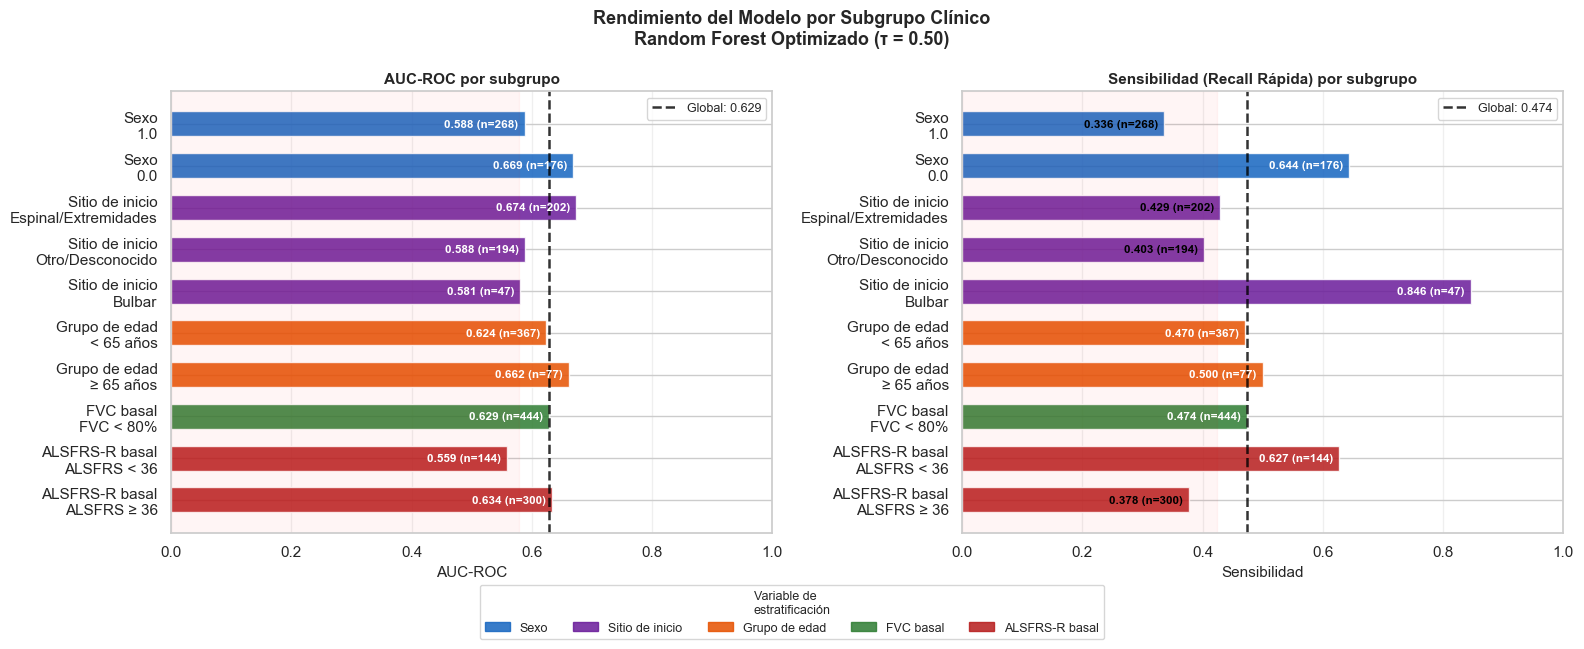

In [42]:
# ============================================================
# CELDA 12.4 — Gráficas de barras AUC y Sensibilidad por subgrupo
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Rendimiento del Modelo por Subgrupo Clínico\nRandom Forest Optimizado (τ = 0.50)',
             fontsize=13, fontweight='bold')

# Preparamos etiquetas combinadas Variable + Subgrupo
df_plot = df_resultados_sg.copy()
df_plot['etiqueta'] = df_plot['Variable'] + '\n' + df_plot['Subgrupo']
df_plot = df_plot.dropna(subset=['AUC-ROC'])

# Paleta de colores por variable
variables_unicas = df_plot['Variable'].unique()
paleta_vars = {
    'Sexo':             '#1565C0',
    'Sitio de inicio':  '#6A1B9A',
    'Grupo de edad':    '#E65100',
    'FVC basal':        '#2E7D32',
    'ALSFRS-R basal':   '#B71C1C',
}
colores_barras = [paleta_vars.get(v, '#607D8B') for v in df_plot['Variable']]

for ax, metrica, titulo in zip(
    axes,
    ['AUC-ROC', 'Sensibilidad'],
    ['AUC-ROC por subgrupo', 'Sensibilidad (Recall Rápida) por subgrupo']
):
    bars = ax.barh(df_plot['etiqueta'], df_plot[metrica],
                   color=colores_barras, edgecolor='white', height=0.6, alpha=0.85)
    
    # Línea de referencia global
    ref_val = global_m[metrica]
    ax.axvline(ref_val, color='black', linestyle='--', linewidth=1.8,
               label=f'Global: {ref_val:.3f}', alpha=0.8)
    
    # Zona de riesgo (por debajo del global - 0.05)
    ax.axvspan(0, ref_val - 0.05, alpha=0.04, color='red')
    
    # Etiquetas de valor en cada barra
    for bar, val, n in zip(bars, df_plot[metrica], df_plot['N']):
        color_txt = 'white' if val > 0.45 else 'black'
        ax.text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f} (n={int(n)})',
                va='center', ha='right', fontsize=8.5, color=color_txt, fontweight='bold')
    
    ax.set_xlabel(metrica, fontsize=11)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim([0, 1.0])
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

# Leyenda de colores por variable
handles_leyenda = [plt.Rectangle((0,0),1,1, color=paleta_vars[v], alpha=0.85)
                   for v in variables_unicas if v in paleta_vars]
fig.legend(handles_leyenda, [v for v in variables_unicas if v in paleta_vars],
           title='Variable de\nestratificación',
           loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.08),
           fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.show()

---
## 12.5 Curvas ROC estratificadas

Más allá del AUC como número resumen, las **curvas ROC por subgrupo** permiten ver si la diferencia entre grupos afecta por igual a todo el espectro de umbrales o si se concentra en una región concreta (por ejemplo, a alta sensibilidad). Esto tiene implicaciones directas para la elección del umbral clínico en cada subpoblación.

Representamos las curvas ROC para los dos subgrupos más relevantes: **sexo** y **sitio de inicio**, que son las variables con mayor sustrato clínico en ELA.

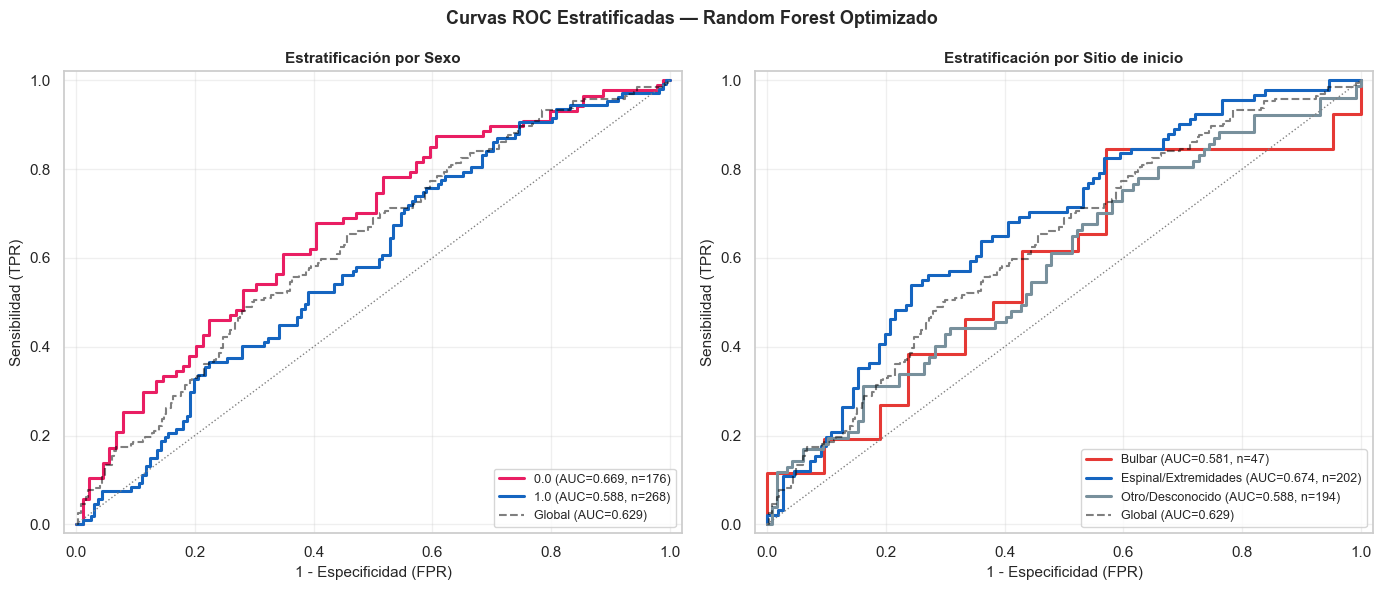

In [43]:
# ============================================================
# CELDA 12.5 — Curvas ROC estratificadas por sexo y sitio de inicio
# ============================================================

variables_roc = [
    ('Sex',          'Sexo',           {'M': '#1565C0', 'F': '#E91E63', 1: '#1565C0', 0: '#E91E63',
                                         'Male': '#1565C0', 'Female': '#E91E63',
                                         'Hombre': '#1565C0', 'Mujer': '#E91E63'}),
    ('sitio_inicio', 'Sitio de inicio', {
        'Bulbar':                     '#E53935',
        'Espinal/Extremidades':       '#1565C0',
        'Mixto (Bulbar+Extremidades)':'#F57F17',
        'Otro/Desconocido':           '#78909C'
    }),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Curvas ROC Estratificadas — Random Forest Optimizado',
             fontsize=13, fontweight='bold')

for ax, (col, titulo, colores_sg) in zip(axes, variables_roc):
    grupos = df_test_sg[col].dropna().unique()
    
    for grupo in sorted(grupos, key=str):
        sub = df_test_sg[df_test_sg[col] == grupo]
        if len(sub) < 10 or len(sub['y_true'].unique()) < 2:
            continue
        
        fpr, tpr, _ = roc_curve(sub['y_true'], sub['y_prob'])
        auc_val      = roc_auc_score(sub['y_true'], sub['y_prob'])
        color        = colores_sg.get(grupo, '#607D8B')
        
        ax.plot(fpr, tpr, linewidth=2.2, color=color,
                label=f'{grupo} (AUC={auc_val:.3f}, n={len(sub)})')
    
    # Curva global de referencia
    fpr_g, tpr_g, _ = roc_curve(df_test_sg['y_true'], df_test_sg['y_prob'])
    ax.plot(fpr_g, tpr_g, linewidth=1.5, color='black', linestyle='--', alpha=0.5,
            label=f'Global (AUC={auc_global:.3f})')
    ax.plot([0,1],[0,1], color='gray', linestyle=':', linewidth=1)
    
    ax.set_xlabel('1 - Especificidad (FPR)', fontsize=11)
    ax.set_ylabel('Sensibilidad (TPR)', fontsize=11)
    ax.set_title(f'Estratificación por {titulo}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()

---
## 12.6 Análisis de errores: ¿dónde falla más el modelo?

Para cerrar el análisis de subgrupos, estudiamos la **distribución de los falsos negativos (FN)** — los pacientes de progresión rápida que el modelo clasifica incorrectamente como lentos. En ELA estos son los errores más peligrosos.

Un FN no distribuido aleatoriamente entre subgrupos indica un **sesgo sistemático del modelo**: está fallando más en un perfil concreto de paciente, lo que tiene implicaciones éticas y clínicas directas para su despliegue.

📊 Pacientes de progresión Rápida en test: 194
   Correctamente clasificados (TP): 92 (47.4%)
   Perdidos como FN:                102 (52.6%)


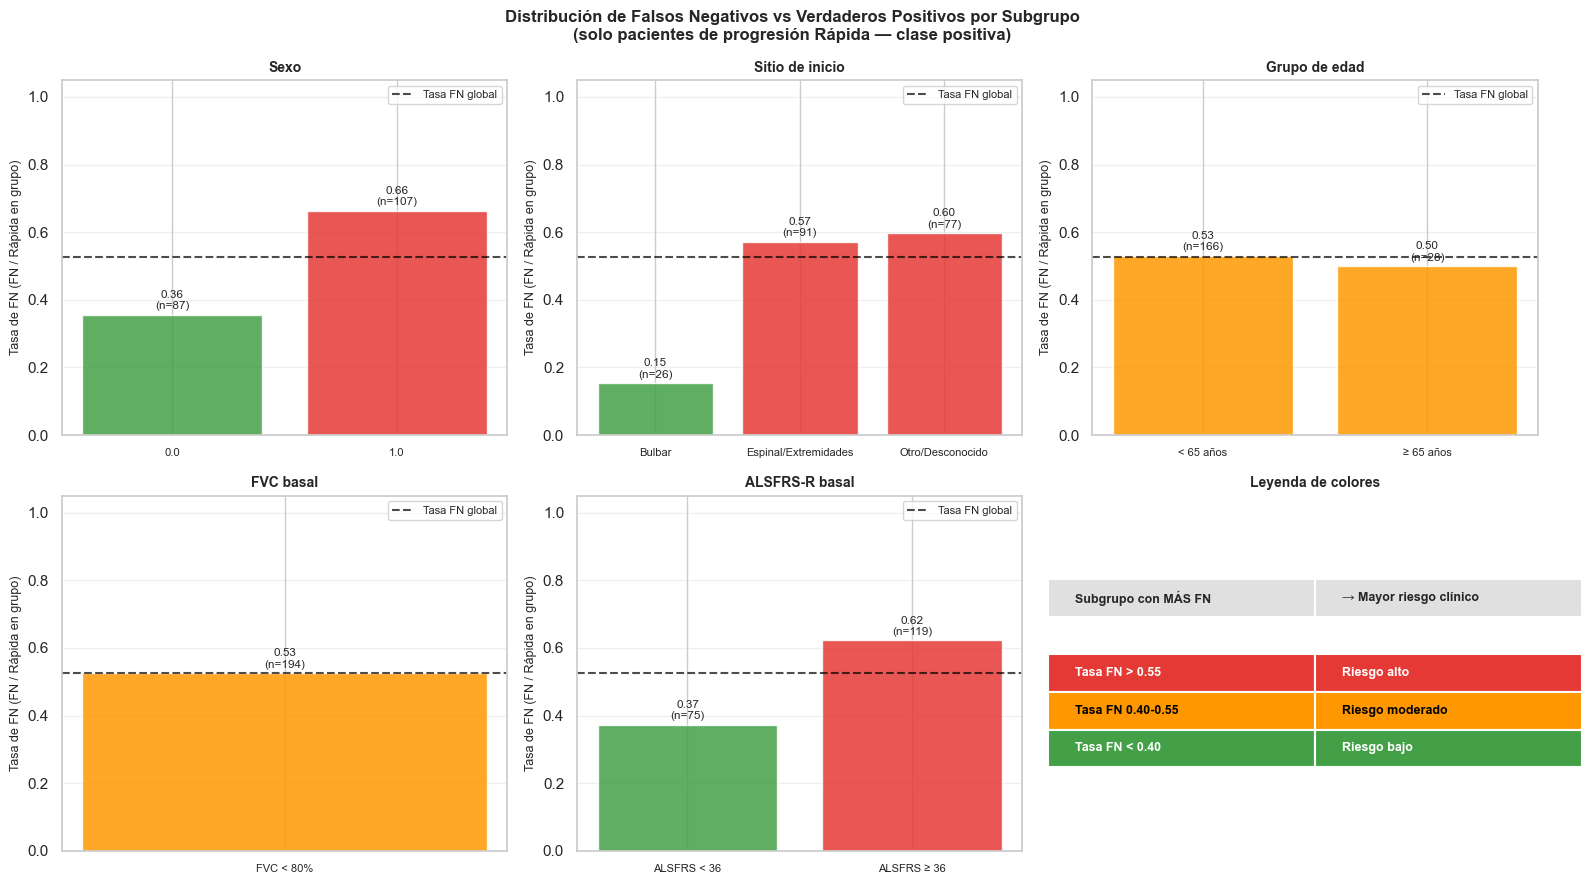

In [44]:
# ============================================================
# CELDA 12.6 — Distribución de falsos negativos por subgrupo
# ============================================================

# Filtramos solo los pacientes Rápida mal clasificados (FN)
df_FN = df_test_sg[(df_test_sg['y_true'] == 1) & (df_test_sg['y_pred'] == 0)].copy()
df_TP = df_test_sg[(df_test_sg['y_true'] == 1) & (df_test_sg['y_pred'] == 1)].copy()
df_rapidos = df_test_sg[df_test_sg['y_true'] == 1].copy()

print(f"📊 Pacientes de progresión Rápida en test: {len(df_rapidos)}")
print(f"   Correctamente clasificados (TP): {len(df_TP)} ({len(df_TP)/len(df_rapidos)*100:.1f}%)")
print(f"   Perdidos como FN:                {len(df_FN)} ({len(df_FN)/len(df_rapidos)*100:.1f}%)")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribución de Falsos Negativos vs Verdaderos Positivos por Subgrupo\n'
             '(solo pacientes de progresión Rápida — clase positiva)',
             fontsize=12, fontweight='bold')

variables_fn = [
    ('Sex',          'Sexo'),
    ('sitio_inicio', 'Sitio de inicio'),
    ('grupo_edad',   'Grupo de edad'),
    ('grupo_fvc',    'FVC basal'),
    ('grupo_alsfrs', 'ALSFRS-R basal'),
]

axes_flat = axes.flatten()

for ax, (col, titulo) in zip(axes_flat[:5], variables_fn):
    # Tasa de FN por grupo (FN / total Rápida en ese grupo)
    grupos = df_rapidos[col].dropna().unique()
    nombres, tasas_fn, n_grupos = [], [], []
    
    for g in sorted(grupos, key=str):
        sub_rap = df_rapidos[df_rapidos[col] == g]
        sub_fn  = df_FN[df_FN[col] == g]
        if len(sub_rap) == 0:
            continue
        tasa = len(sub_fn) / len(sub_rap)
        nombres.append(str(g))
        tasas_fn.append(tasa)
        n_grupos.append(len(sub_rap))
    
    colores_fn = ['#E53935' if t > 0.55 else '#FF9800' if t > 0.40 else '#43A047'
                  for t in tasas_fn]
    
    bars = ax.bar(nombres, tasas_fn, color=colores_fn, edgecolor='white', alpha=0.85)
    ax.axhline(len(df_FN)/len(df_rapidos), color='black', linestyle='--',
               linewidth=1.5, alpha=0.7, label='Tasa FN global')
    
    for bar, tasa, n in zip(bars, tasas_fn, n_grupos):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{tasa:.2f}\n(n={n})', ha='center', va='bottom', fontsize=8.5)
    
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_ylabel('Tasa de FN (FN / Rápida en grupo)', fontsize=9)
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=8)

# Último panel: tabla resumen
ax_tab = axes_flat[5]
ax_tab.axis('off')

tabla_resumen = [
    ['Subgrupo con MÁS FN', '→ Mayor riesgo clínico'],
    ['', ''],
    ['Tasa FN > 0.55', 'Riesgo alto'],
    ['Tasa FN 0.40-0.55', 'Riesgo moderado'],
    ['Tasa FN < 0.40', 'Riesgo bajo']
]

tab = ax_tab.table(
    cellText=tabla_resumen,
    loc='center',
    cellLoc='left'
)

tab.auto_set_font_size(False)
tab.set_fontsize(9)
tab.scale(1.2, 2.0)

# Estilo general de bordes
for key, cell in tab.get_celld().items():
    cell.set_edgecolor('white')
    cell.set_linewidth(1.5)

# Encabezado
for c in range(2):
    tab[(0, c)].set_facecolor('#E0E0E0')
    tab[(0, c)].set_text_props(weight='bold')

# Filas de colores
for c in range(2):
    tab[(2, c)].set_facecolor('#E53935')   # rojo
    tab[(2, c)].set_text_props(color='white', weight='bold')

    tab[(3, c)].set_facecolor('#FF9800')   # naranja
    tab[(3, c)].set_text_props(color='black', weight='bold')

    tab[(4, c)].set_facecolor('#43A047')   # verde
    tab[(4, c)].set_text_props(color='white', weight='bold')

ax_tab.set_title('Leyenda de colores', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Exportación

In [45]:
# ============================================================
# EXPORTACIÓN PARA NOTEBOOK 4
# ============================================================

import os
import joblib

# Ruta de salida
ruta_out = r"C:\Users\Paula\SAD_ELA\datos_procesados"
os.makedirs(ruta_out, exist_ok=True)

# ─────────────────────────────────────────────
# 1. DATASETS
# ─────────────────────────────────────────────

# X_test (variables del test)
X_test.to_csv(
    ruta_out + r"\X_test.csv",
    index=True,
    decimal=',',
    sep=';'
)

# y_test (verdad real)
y_test.to_csv(
    ruta_out + r"\y_test.csv",
    index=True,
    decimal=',',
    sep=';'
)

# Dataset completo
X.to_csv(
    ruta_out + r"\X_full.csv",
    index=True,
    decimal=',',
    sep=';'
)

# ─────────────────────────────────────────────
# 2. PREDICCIONES DEL MODELO
# ─────────────────────────────────────────────

np.save(ruta_out + r"\y_pred_rf_opt.npy", y_pred_rf_opt)
np.save(ruta_out + r"\y_prob_rf_opt.npy", y_prob_rf_opt)

# ─────────────────────────────────────────────
# 3. SHAP
# ─────────────────────────────────────────────

np.save(ruta_out + r"\shap_rapida.npy", shap_rapida)

# ─────────────────────────────────────────────
# 4. MODELO ENTRENADO
# ─────────────────────────────────────────────

joblib.dump(rf_opt, ruta_out + r"\rf_opt.pkl")

# ─────────────────────────────────────────────
# CONFIRMACIÓN
# ─────────────────────────────────────────────

print("✅ Exportación completada en:", ruta_out)
print("Archivos generados:")
print(" - X_test.csv")
print(" - y_test.csv")
print(" - X_full.csv")
print(" - y_pred_rf_opt.npy")
print(" - y_prob_rf_opt.npy")
print(" - shap_rapida.npy")
print(" - rf_opt.pkl")

✅ Exportación completada en: C:\Users\Paula\SAD_ELA\datos_procesados
Archivos generados:
 - X_test.csv
 - y_test.csv
 - X_full.csv
 - y_pred_rf_opt.npy
 - y_prob_rf_opt.npy
 - shap_rapida.npy
 - rf_opt.pkl


## 13. Exportación del modelo para la aplicación Streamlit

Se guardan los tres artefactos necesarios para que la app funcione sin reentrenamiento:

- `rf_opt.pkl` — Random Forest optimizado tras Grid Search
- `scaler.pkl` — StandardScaler ajustado exclusivamente sobre train (previene data leakage)
- `feature_names.json` — orden exacto de las 20 variables predictoras

La verificación final comprueba que el modelo recargado produce el mismo rango de probabilidades que el entrenado en memoria.

In [46]:
# ============================================================
# EXPORTACIÓN PARA LA APLICACIÓN STREAMLIT
# ============================================================
import joblib, json, os
import numpy as np

ruta_app = r"C:\Users\Paula\SAD_ELA\app_streamlit"
os.makedirs(ruta_app, exist_ok=True)

# 1. Modelo Random Forest optimizado (entrenado con Grid Search)
joblib.dump(rf_opt, ruta_app + r"\rf_opt.pkl")

# 2. Scaler ajustado sobre train — mismo que se usó en X_train_scaled
joblib.dump(scaler, ruta_app + r"\scaler.pkl")

# 3. Orden exacto de variables — crítico para que la app construya
#    el vector de entrada en el mismo orden que vio el modelo
feature_names_list = X.columns.tolist()
with open(ruta_app + r"\feature_names.json", "w") as f:
    json.dump(feature_names_list, f)

# ── Verificación de integridad ──────────────────────────────
modelo_check  = joblib.load(ruta_app + r"\rf_opt.pkl")
scaler_check  = joblib.load(ruta_app + r"\scaler.pkl")

X_test_check  = scaler_check.transform(X_test)
probas_check  = modelo_check.predict_proba(X_test_check)[:, 1]
probas_orig   = rf_opt.predict_proba(X_test_scaled)[:, 1]
iguales       = np.allclose(probas_orig, probas_check, atol=1e-6)

print("✅ Archivos guardados en:", ruta_app)
print(f"   - rf_opt.pkl")
print(f"   - scaler.pkl")
print(f"   - feature_names.json  →  {feature_names_list}")
print(f"\nRango probabilidades original : {probas_orig.min():.3f} → {probas_orig.max():.3f}")
print(f"Rango probabilidades recargado: {probas_check.min():.3f} → {probas_check.max():.3f}")
if iguales:
    print("\n✅ Verificación superada — modelo guardado idéntico al entrenado.")
else:
    print("\n⚠️  Discrepancia detectada: revisar el proceso de guardado.")


✅ Archivos guardados en: C:\Users\Paula\SAD_ELA\app_streamlit
   - rf_opt.pkl
   - scaler.pkl
   - feature_names.json  →  ['Age', 'Sex', 'alsfrs_basal_total', 'basal_bulbar', 'basal_motor_fino', 'basal_motor_grueso', 'basal_respiratorio', 'onset_limb', 'onset_bulbar', 'onset_spine', 'onset_limb_bulbar', 'onset_other', 'onset_unknown', 'fvc_basal', 'weight_basal', 'albumin', 'creatine_kinase', 'creatinine', 'uric_acid', 'uric_acid_unknown']

Rango probabilidades original : 0.376 → 0.451
Rango probabilidades recargado: 0.376 → 0.451

✅ Verificación superada — modelo guardado idéntico al entrenado.
